### Read in all the data

In [1]:
'''Import all needed libraries'''
import xarray as xr
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cftime
import random
import nc_time_axis
import datetime
import os
from   cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
from   scipy.stats import linregress, pearsonr


# Import weights for each lat-lon grid point since they have different sizes for different latitudes
area_weights = xr.open_mfdataset('area_weights.nc')

In [3]:
'''Read in the datasets (ca. 4min)'''
print('ssh')
dataset_ssh = {}
for i in range(1948, 2011):
    path_pattern = f"../ensemble_65/member_65_{i}/member_65_{i}_*/*.ocean_sfc.nc"
    files = glob.glob(path_pattern)
    if files:
        dataset_ssh[i] = xr.open_mfdataset(
            files,
            combine='nested',
            concat_dim='time',
            preprocess= lambda dataset_ssh:dataset_ssh['SSH'],  # select wanted data variables
            #decode_times=xr.coding.times.CFDatetimeCoder(use_cftime=True)
        )
        dataset_ssh[i] = dataset_ssh[i].sortby('time')  # If that years run didn't finish
    else:
        dataset_ssh[i] = []

print('sst')
dataset_sst = {}
for i in range(1948, 2011):
    path_pattern = f"../ensemble_65/member_65_{i}/member_65_{i}_*/*.ocean_sfc.nc"
    files = glob.glob(path_pattern)
    if files:
        dataset_sst[i] = xr.open_mfdataset(
            files,
            combine='nested',
            concat_dim='time',
            preprocess= lambda dataset_sst:dataset_sst['SST'],  # select wanted data variables
            decode_times=xr.coding.times.CFDatetimeCoder(use_cftime=True)
        )
        dataset_sst[i] = dataset_sst[i].sortby('time')  # If that years run crashed
    else:
        dataset_sst[i] = []

print('sss')
dataset_sss = {}
for i in range(1948, 2011):
    path_pattern = f"../ensemble_65/member_65_{i}/member_65_{i}_*/*.ocean_sfc.nc"
    files = glob.glob(path_pattern)
    if files:
        dataset_sss[i] = xr.open_mfdataset(
            files,
            combine='nested',
            concat_dim='time',
            preprocess= lambda dataset_sss:dataset_sss['SSS'],  # select wanted data variables
            decode_times=xr.coding.times.CFDatetimeCoder(use_cftime=True)
        )
        dataset_sss[i] = dataset_sss[i].sortby('time')  # sort the concatenated files along time dimension
    else:
        dataset_sss[i] = []  # If that years run crashed

print('ice')
dataset_ice = {}
for i in range(1948, 2011):
    path_pattern = f"../ensemble_65/member_65_{i}/member_65_{i}_*/*.ice_month.nc"
    files = glob.glob(path_pattern)
    if files:
        dataset_ice[i] = xr.open_mfdataset(
            files,
            combine='nested',
            concat_dim='time',
            preprocess= lambda dataset_ice:dataset_ice['EXT'],  # select wanted data variables
            decode_times=xr.coding.times.CFDatetimeCoder(use_cftime=True)
        )
        dataset_ice[i] = dataset_ice[i].sortby('time')  # sort the concatenated files along time dimension
        dataset_ice[i] = dataset_ice[i].rename({'xT': 'xh', 'yT': 'yh'})
    else:
        dataset_ice[i] = []   # If that years run crashed
   

print('salt')
dataset_salt = {}
for i in range(1948, 2011):
    path_pattern = f"../ensemble_65/member_65_{i}/member_65_{i}_*/ocean.stats.nc"
    files = glob.glob(path_pattern)
    if files:
        dataset_salt[i] = xr.open_mfdataset(
            files,
            combine='nested',
            concat_dim='Time',
            preprocess= lambda dataset_salt:dataset_salt['Salt'],  # select wanted data variables
            decode_times=False,  # values of time coordinate are weird and will be adapted below
        )
        dataset_salt[i] = dataset_salt[i].sortby('Time')

        # Each year has time values from 01.01.YearX 0:00 to 31.12.YearX 24:00, the latter is equal to 01.01.YearX+1, which is also the first value of the next year. After concatenation the same point in time appears twice in a row.
        # The following mask identifies these double entries and removes one of them.
        time_values             = dataset_salt[i]['Time'].values
        duplicate_indices       = np.where(np.diff(time_values) == 0)[0]  # identify equal consecutive values along the Time coordinate
        mask                    = np.ones(time_values.shape, dtype=bool)  # create a mask with same shape as time coordinates with all values True
        mask[duplicate_indices] = False  # sets all double index points to False
        dataset_salt[i]         = dataset_salt[i].isel(Time=mask)  # apply mask to ds to remove double entries
        dataset_salt[i]         = dataset_salt[i].assign_coords(Time = pd.date_range(start=f"{i}-01", end=f"{i+10}-01", freq="6h"))
    else:
        dataset_salt[i]         = []   # If that years run crashed


print('heat')
dataset_heat = {}
for i in range(1948, 2011):
    path_pattern = f"../ensemble_65/member_65_{i}/member_65_{i}_*/ocean.stats.nc"
    files = glob.glob(path_pattern)
    if files:
        dataset_heat[i] = xr.open_mfdataset(
            files,
            combine='nested',
            concat_dim='Time',
            preprocess= lambda dataset_heat:dataset_heat['Heat'],  # select wanted data variables
            decode_times=False,  # values of time coordinate are weird and will be adapted below
        )
        dataset_heat[i] = dataset_heat[i].sortby('Time')  # sort the concatenated files along time dimension

        # Each year has time values from 01.01.YearX 0:00 to 31.12.YearX 24:00, the latter is equal to 01.01.YearX+1, which is also the first value of the next year. After concatenation the same point in time appears twice in a row.
        # The following mask identifies these double entries and removes one of them.
        time_values             = dataset_heat[i]['Time'].values
        duplicate_indices       = np.where(np.diff(time_values) == 0)[0]  # identify equal consecutive values along the Time coordinate
        mask                    = np.ones(time_values.shape, dtype=bool)  # create a mask with same shape as time coordinates with all values True
        mask[duplicate_indices] = False  # sets all double index points to False
        dataset_heat[i]         = dataset_heat[i].isel(Time=mask)  # apply mask to ds to remove double entries
        dataset_heat[i]         = dataset_heat[i].assign_coords(Time = pd.date_range(start=f"{i}-01", end=f"{i+10}-01", freq="6h"))
    else:
        dataset_heat[i]         = []  # If that years run crashed

ssh


sst
sss
ice
salt
heat


In [4]:
'''Add initial conditions from refrun to files where it's not included already'''
# Compute initial conditions of SSS, SSH, SST
# Initial ice cover extent not given in ice_model.res.nc
# Initial heat and salt already included in the ds
MOM_init = xr.open_mfdataset("../ensemble_65/initial_field/MOM.res.nc", decode_times=False)
MOM_init = MOM_init.rename({'lath': 'yh', 'lonh': 'xh'}).isel(Time=0,Layer=0)
SST_init = (MOM_init['Temp'] * area_weights['area_t']).sum(dim=["xh", "yh"])
SSS_init = (MOM_init['Salt'] * area_weights['area_t']).sum(dim=["xh", "yh"])
SSH_init = (MOM_init['sfc'] * area_weights['area_t']).sum(dim=["xh", "yh"])

In [5]:
'''Get refrun data'''
# Import reference run data, modify time coordinate, and add initial values
timemask = dataset_sss[1965].time[:-1]  # time mask 

refrun_ssh = xr.open_dataset("reference_run_time_series/reference_run_SSH.nc").rename({"__xarray_dataarray_variable__": "SSH"})
refrun_ssh = refrun_ssh.sel(time=timemask)['SSH'].rename({"time": "month"}).assign_coords(month=range(1,120))  # modifiy time coord
refrun_ssh = xr.concat([xr.DataArray(data=[SSH_init.values], coords={"month": [0]}, dims=("month",)), refrun_ssh], dim="month")  # add initial value

refrun_sst = xr.open_dataset("reference_run_time_series/reference_run_SST.nc").rename({"__xarray_dataarray_variable__": "SST"})
refrun_sst = refrun_sst.sel(time=timemask)['SST'].rename({"time": "month"}).assign_coords(month=range(1,120))  # modifiy time coord
refrun_sst = xr.concat([xr.DataArray(data=[SST_init.values], coords={"month": [0]}, dims=("month",)), refrun_sst], dim="month")  # add initial value

refrun_sss = xr.open_dataset("reference_run_time_series/reference_run_SSS.nc").rename({"__xarray_dataarray_variable__": "SSS"})
refrun_sss = refrun_sss.sel(time=timemask)['SSS'].rename({"time": "month"}).assign_coords(month=range(1,120))  # modifiy time coord
refrun_sss = xr.concat([xr.DataArray(data=[SSS_init.values], coords={"month": [0]}, dims=("month",)), refrun_sss], dim="month")  # add initial value

refrun_ice = xr.open_dataset("reference_run_time_series/reference_run_ice.nc").rename({"__xarray_dataarray_variable__": "EXT"})
refrun_ice = refrun_ice.sel(time=slice("1965-01", "1974-12"))['EXT'].rename({"time": "month"}).assign_coords(month=range(1,121))  # modifiy time coord

refrun_salt = xr.open_dataset("reference_run_time_series/reference_run_salt.nc")
refrun_salt = refrun_salt.sel(Time=slice("1965-01-01", "1974-12-31"))['Salt']  # modifiy time coord
salt_init   = refrun_salt[0].values
refrun_salt = refrun_salt.resample(Time='ME').mean().rename({"Time": "month"}).assign_coords(month=range(1,121))
refrun_salt = xr.DataArray(np.insert(refrun_salt.values, 0, salt_init), coords=[np.insert(refrun_salt.month.values, 0, 0)], dims=['month'])  # add back the inital value after averaging
refrun_salt = refrun_salt.sel(month=slice(0,119))

refrun_heat = xr.open_dataset("reference_run_time_series/reference_run_heat.nc")
refrun_heat = refrun_heat.sel(Time=slice("1965-01-01", "1974-12-31"))['Heat']  # modifiy time coord
heat_init   = refrun_heat[0].values
refrun_heat = refrun_heat.resample(Time='ME').mean().rename({"Time": "month"}).assign_coords(month=range(1,121))
refrun_heat = xr.DataArray(np.insert(refrun_heat.values, 0, heat_init), coords=[np.insert(refrun_heat.month.values, 0, 0)], dims=['month'])  # add back the inital value after averaging
refrun_heat = refrun_heat.sel(month=slice(0,119))

In [ ]:
'''Define used functions'''
# Define function to average over BS and modify time coord
def process_monthly_ds(ds,var): # for ssh,sst,sss and ice
    # ds - modified dataarray
    # var - 'salt' or 'heat', used for including the initial value
    dataset_mean = {}
    for year in ds:
        if len(ds[year]) > 0:  # check if a year contains [] because of corrupted data
            dataset_mean[year] = (ds[year] * area_weights['area_t']).sum(dim=["xh", "yh"])  # compute averages over whole Baltic Sea with area_weights weighing in the size of each grid point
            months_array = range(1, len(ds[year].time)+1)  # create months array as new time dim values
            dataset_mean[year] = dataset_mean[year].rename({'time': 'month'}).assign_coords(month=months_array)
            if var in ["SSH", "SST", "SSS"]:  # Got no initial value for Ice
                dataset_mean[year] = xr.concat([xr.DataArray(data=[globals()[f"{var}_init"].values], coords={"month": [0]}, dims=("month",)), dataset_mean[year]], dim="month")  # add initial value
    dataset_mean = xr.Dataset(dataset_mean).to_array(dim='year')
    return dataset_mean

# Define function to modify time coord
def process_6h_ds(ds, var): # for salt and heat, no average needed over BS
    # ds - modified dataarray
    # var - 'salt' or 'heat', used for including the initial value
    dataset_new = {}
    for year in ds:
        if len(ds[year]) > 0:  # check if a year contains [] because of corrupted data
            time_array = range(1, len(ds[year].Time)+1)  # create time array as new time dim values
            dataset_new[year] = ds[year].rename({'Time': 'timestep_6h'}).assign_coords(timestep_6h=time_array)
    dataset_new = xr.Dataset(dataset_new).to_array(dim='year')
    # Modify from 6-hourly(so far called 'timestep_6h') -> monthly values
    dataset_new                = dataset_new.isel(timestep_6h=slice(1, None)).coarsen(timestep_6h=122, boundary="trim").mean()  # averaging over 122 values (6h -> avergae month), leaving out the initial value which is added again below
    dataset_new['timestep_6h'] = range(1, len(dataset_new['timestep_6h'])+1)  # rename timestep_6h coordinate values
    dataset_new                = dataset_new.rename({'timestep_6h': 'month'})  # rename timestep_6h coord to month
    # Add initial value for month=0
    init_value  = xr.DataArray(np.full((len(dataset_new.year), 1), globals()[f"{var}_init"] ), coords={'year': dataset_new.year, 'month': np.array([0])}, dims=['year', 'month'])
    dataset_new = xr.concat([init_value, dataset_new], dim='month')
    return dataset_new

# Define function to remove annual cycle from datset with monthly values (_mo) - so for sst,ssh,sss,ice
def remove_annual_cycle_mo(ds):
    monthly_mean = {}
    if 0 in ds['month'].values:
        for i in range (1,13):
            monthly_mean[i] = np.mean(ds[i::12])  # extracts every 12th element starting from i -> since i starts at 0, initial values are being skipped
            rest = i
            if i == 12:
                rest = 0
            mask = ds['month'] % 12 == rest
            ds = ds.where(~mask, ds - monthly_mean[i])
    else:
        for i in range (12):
            monthly_mean[i+1] = np.mean(ds[i::12])  # extracts every 12th element starting from i -> since i starts at 0, initial values are being skipped
            rest = i+1
            if i == 11:
                rest = 0
            mask = ds['month'] % 12 == rest
            ds = ds.where(~mask, ds - monthly_mean[i+1])
    ds = ds.where(ds['month'] != 0, 0)  # set initial value to zero
    monthly_mean = xr.Dataset(monthly_mean).to_array(dim='month')
    return ds, monthly_mean

# Compute root mean square error (rmse) & mean absolute error (mae) & pearson correlation (corr) between subset of 1-63 members and the ensemble mean
def get_errors(ds, ensemble_mean):
    rmse = {}
    mae  = {}
    corr = {}
    for i in range (1,64): 
        random_years = random.sample(ds.year.values.tolist(), i) 
        subset       = ds.sel(year=random_years)
        subset_mean  = subset.mean(dim='year')
        rmse[i]      = np.sqrt(np.mean(((subset_mean - ensemble_mean) / ensemble_mean) **2 ))  # compute rmse
        mae[i]       = np.mean(np.abs((subset_mean - ensemble_mean) / ensemble_mean))  # compute mae
        corr[i], _   = pearsonr(subset_mean.values, ensemble_mean.values)  # compute pearson correlation cooefficient
    rmse = xr.Dataset(rmse).to_array(dim='member_nr')
    mae  = xr.Dataset(mae).to_array(dim='member_nr')
    corr = xr.Dataset(corr).to_array(dim='member_nr')
    return rmse, mae, corr


# Subsample years for initial Heat, Salt, SST, SSH, SSS 
def get_high_low_within_years(timeseries_0101, detrend):
    # timeseries_0101  - input timeseries
    # detrend          - if 0: no detrend, if 1: remove linear trend from time series
    years                = timeseries_0101['time'].dt.year
    # Detrend the time series, makes sense for temperature related variables
    if detrend == 1:
        slope, intercept, *_ = linregress(years.values, timeseries_0101.values)
        timeseries_detrended = timeseries_0101 - slope * years + intercept
        timeseries_0101      = timeseries_detrended
    # Compute category thresholds
    mean_val = timeseries_0101.mean()
    std_val  = timeseries_0101.std()
    strong_pos   = years.where((timeseries_0101 > mean_val + std_val).compute(), drop=True).values
    moderate_pos = years.where(((timeseries_0101 > mean_val + 0.5 * std_val) & (timeseries_0101 <= mean_val + std_val)).compute(), drop=True).values
    neutral      = years.where(((timeseries_0101 >= mean_val - 0.5 * std_val) & (timeseries_0101 <= mean_val + 0.5 * std_val)).compute(), drop=True).values
    moderate_neg = years.where(((timeseries_0101 < mean_val - 0.5 * std_val) & (timeseries_0101 >= mean_val - std_val)).compute(), drop=True).values
    strong_neg   = years.where((timeseries_0101 < mean_val - std_val).compute(), drop=True).values
    return strong_pos, moderate_pos, neutral, moderate_neg, strong_neg


In [7]:
'''Process datsets'''
# Unify time coordinate (process function), and compute ensemble mean and standard deviation
ds_ssh       = process_monthly_ds(dataset_ssh, "SSH")
ssh_ens_mean = ds_ssh.mean(dim='year')
ssh_ens_std  = ds_ssh.std(dim='year')
ds_sst       = process_monthly_ds(dataset_sst, "SST")
sst_ens_mean = ds_sst.mean(dim='year')
sst_ens_std  = ds_sst.std(dim='year')
ds_sss       = process_monthly_ds(dataset_sss, "SSS")
sss_ens_mean = ds_sss.mean(dim='year')
sss_ens_std  = ds_sss.std(dim='year')
ds_ice       = process_monthly_ds(dataset_ice, "ice")
ice_ens_mean = ds_ice.mean(dim='year')
ice_ens_std  = ds_ice.std(dim='year')
ds_heat       = process_6h_ds(dataset_heat, "heat")
heat_ens_mean = ds_heat.mean(dim='year')
heat_ens_std  = ds_heat.std(dim='year')
ds_salt       = process_6h_ds(dataset_salt, "salt")
salt_ens_mean = ds_salt.mean(dim='year')
salt_ens_std  = ds_salt.std(dim='year')

In [8]:
'''Compute above calculated datasets (ca. 3min)'''
ds_heat = ds_heat.compute()
ds_salt = ds_salt.compute()
ds_sst  = ds_sst.compute()
ds_sss  = ds_sss.compute()
ds_ssh  = ds_ssh.compute()
ds_ice  = ds_ice.compute()
heat_ens_mean = heat_ens_mean.compute()
salt_ens_mean = salt_ens_mean.compute()
sst_ens_mean  = sst_ens_mean.compute()
sss_ens_mean  = sss_ens_mean.compute()
ssh_ens_mean  = ssh_ens_mean.compute()
ice_ens_mean  = ice_ens_mean.compute()
heat_ens_std = heat_ens_std.compute()
salt_ens_std = salt_ens_std.compute()
sst_ens_std  = sst_ens_std.compute()
sss_ens_std  = sss_ens_std.compute()
ssh_ens_std  = ssh_ens_std.compute()
ice_ens_std  = ice_ens_std.compute()

### Import NAO & AMV & precipitation stuff

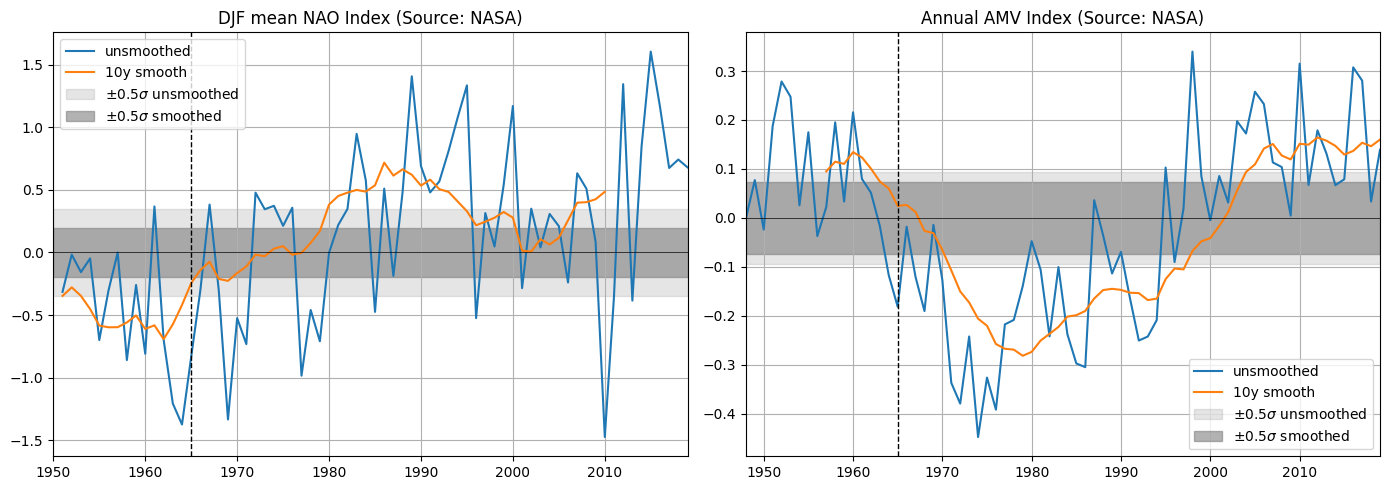

In [9]:
'''Import NAO & AMV index time series'''

# NAO
df = pd.read_csv("NAO_index.txt", sep=r'\s+', header=None)  # read in the file
df.columns = ['year'] + [f'{month:02d}' for month in range(1, 13)]  # name columns
df['JFM_mean'] = df[['01', '02', '03']].astype(float).mean(axis=1)
df['DJF_mean'] = df['12'].shift(1).astype(float).add(df['01'].astype(float)).add(df['02'].astype(float)).add(df['03'].astype(float)) / 4
df['ND_mean']  = df[['11', '12']].astype(float).mean(axis=1)
df['December'] = df[['12']].astype(float)
ds_NAO_DJF = xr.DataArray(data=df['DJF_mean'].values, coords={'time': pd.to_datetime(df['year'], format='%Y')}, dims='time', name='NAO_index').to_dataset()  # transform to wished format: dataset
ds_NAO_ND  = xr.DataArray(data=df['ND_mean'].values, coords={'time': pd.to_datetime(df['year'], format='%Y')}, dims='time', name='NAO_index').to_dataset()  # transform to wished format: dataset
ds_NAO_D   = xr.DataArray(data=df['December'].values, coords={'time': pd.to_datetime(df['year'], format='%Y')}, dims='time', name='NAO_index').to_dataset()  # transform to wished format: dataset
ds_NAO_DJF_smooth = ds_NAO_DJF['NAO_index'].rolling(time=10, center=False).mean().shift(time=-9)  # compute 10y smooth
NAO_DJF_std    = ds_NAO_DJF.std()['NAO_index'].values
NAO_ND_std     = ds_NAO_ND.std()['NAO_index'].values
NAO_D_std      = ds_NAO_D.std()['NAO_index'].values
NAO_smooth_std = ds_NAO_DJF_smooth.std().values
# AMV
df = pd.read_csv("AMV_index.txt", sep=r'\s+', header=None)  # read in the file
df.columns = ['year'] + [f'{month:02d}' for month in range(1, 13)]  # name columns
df['annual_mean'] = df.iloc[:, 1:].mean(axis=1)  # Compute annual mean AMV index
ds_AMV             = xr.DataArray(data=df['annual_mean'].values, coords={'time': pd.to_datetime(df['year'], format='%Y')}, dims='time', name='AMV_index').to_dataset()  # transform to wished format: dataset
AMV_std            = ds_AMV.std()['AMV_index'].values
ds_AMV_10y_smooth  = ds_AMV['AMV_index'].rolling(time=10, center=False).mean() # compute previous 10y smooth
AMV_10y_smooth_std = ds_AMV_10y_smooth.std().values
ds_AMV_7y_smooth   = ds_AMV['AMV_index'].rolling(time=7, center=False).mean()  # compute previous 7y smooth
AMV_7y_smooth_std  = ds_AMV_7y_smooth.std().values
ds_AMV_5y_smooth   = ds_AMV['AMV_index'].rolling(time=5, center=False).mean()  # compute previous 5y smooth
AMV_5y_smooth_std  = ds_AMV_5y_smooth.std().values
ds_AMV_3y_smooth   = ds_AMV['AMV_index'].rolling(time=3, center=False).mean()  # compute previous 3y smooth
AMV_3y_smooth_std  = ds_AMV_3y_smooth.std().values


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
# NAO Plot
axes[0].plot(ds_NAO_DJF['time'], ds_NAO_DJF['NAO_index'], alpha=1, label='unsmoothed')
axes[0].plot(ds_NAO_DJF['time'], ds_NAO_DJF_smooth, alpha=1, label='10y smooth')
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].fill_between(ds_NAO_DJF['time'], -0.5*NAO_DJF_std, 0.5*NAO_DJF_std, color='gray', alpha=0.2, label=r"$\pm 0.5\sigma$ unsmoothed")
axes[0].fill_between(ds_NAO_DJF['time'], -0.5*NAO_smooth_std, 0.5*NAO_smooth_std, color='gray', alpha=0.6, label=r"$\pm 0.5\sigma$ smoothed")
axes[0].set_xlim(ds_NAO_DJF['time'][0], ds_NAO_DJF['time'][-1])
axes[0].set_title('DJF mean NAO Index (Source: NASA)')
axes[0].axvline(datetime.datetime(1965, 1, 1), c='k', ls='--', lw=1)
axes[0].legend()
axes[0].grid()
# AMV Plot
axes[1].plot(ds_AMV['time'], ds_AMV['AMV_index'], alpha=1, label='unsmoothed')
axes[1].plot(ds_AMV['time'], ds_AMV_10y_smooth, alpha=1, label='10y smooth')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].fill_between(ds_AMV['time'], -0.5*AMV_std, 0.5*AMV_std, color='gray', alpha=0.2, label=r"$\pm 0.5\sigma$ unsmoothed")
axes[1].fill_between(ds_AMV['time'], -0.5*AMV_10y_smooth_std, 0.5*AMV_10y_smooth_std, color='gray', alpha=0.6, label=r"$\pm 0.5\sigma$ smoothed")
axes[1].set_xlim(ds_AMV['time'][0], ds_AMV['time'][-1])
axes[1].set_title('Annual AMV Index (Source: NASA)')
axes[1].axvline(datetime.datetime(1965, 1, 1), c='k', ls='--', lw=1)
axes[1].legend()
axes[1].grid()
plt.tight_layout()

In [ ]:
# ''' Import runfoff data '''

# base_dir = os.path.expanduser("~/../../data/iow/database/RIVER/level-2/reconstruction-1850-2000/8nm/RiverDat_CDOM_V05")
# years    = range(1938,2020)
# datasets = []

# for year in years:
#     path =f"{base_dir}/{year}/runoff.nc"
#     if os.path.exists(path):  # Check if file exists
#         ds = xr.open_mfdataset(path, decode_times=False, preprocess = lambda ds:ds['runoff'])
#         ds = ds.isel(time=slice(2, None))
#         ds = ds['runoff'].mean(dim='time')  # Drop the first two time values, as they are repeated from the previous year
#         ds = ds.rename({'lon': 'xh', 'lat': 'yh'})
#         datasets.append(ds)
#     else:
#         print(f"No file found for year {year}")

# years = range(1938,2020)
# runoff = xr.concat(datasets, dim='time').assign_coords(time = [datetime.datetime(year, 1, 1) for year in years]).compute()

In [ ]:
# runoff_3y_smooth = runoff.sum(dim=["xh","yh"]).rolling(time=3, center=False).mean().sel(time=slice(datetime.datetime(1948, 1, 1),datetime.datetime(2011, 1, 1)))
# runoff_5y_smooth = runoff.sum(dim=["xh","yh"]).rolling(time=5, center=False).mean().sel(time=slice(datetime.datetime(1948, 1, 1),datetime.datetime(2011, 1, 1)))
# runoff_7y_smooth = runoff.sum(dim=["xh","yh"]).rolling(time=3, center=False).mean().sel(time=slice(datetime.datetime(1948, 1, 1),datetime.datetime(2011, 1, 1)))
# runoff_10y_smooth = runoff.sum(dim=["xh","yh"]).rolling(time=10, center=False).mean().sel(time=slice(datetime.datetime(1948, 1, 1),datetime.datetime(2011, 1, 1)))

# years_runoff_3y_strong_pos, years_runoff_3y_moderate_pos, years_runoff_3y_neutral, years_runoff_3y_moderate_neg, years_runoff_3y_strong_neg = get_high_low_within_years(runoff_3y_smooth, detrend=0)
# years_runoff_5y_strong_pos, years_runoff_5y_moderate_pos, years_runoff_5y_neutral, years_runoff_5y_moderate_neg, years_runoff_5y_strong_neg = get_high_low_within_years(runoff_5y_smooth, detrend=0)
# years_runoff_7y_strong_pos, years_runoff_7y_moderate_pos, years_runoff_7y_neutral, years_runoff_7y_moderate_neg, years_runoff_7y_strong_neg = get_high_low_within_years(runoff_7y_smooth, detrend=0)
# years_runoff_10y_strong_pos, years_runoff_10y_moderate_pos, years_runoff_10y_neutral, years_runoff_10y_moderate_neg, years_runoff_10y_strong_neg = get_high_low_within_years(runoff_10y_smooth, detrend=0)

NameError: name 'runoff' is not defined

In [ ]:
''' Calculate years for NAO & AMY subampling '''
# Create subset years for smoothed and unsmoothed timeseries of AMV
# Extract years for plus/minus/neutral AMV
strong_pos   = ds_AMV['AMV_index'][:-9] >= 1.0 * AMV_std
moderate_pos = (ds_AMV['AMV_index'][:-9] >= 0.5 * AMV_std) & (ds_AMV['AMV_index'][:-9] < 1.0 * AMV_std)
neutral      = (ds_AMV['AMV_index'][:-9] > -0.5 * AMV_std) & (ds_AMV['AMV_index'][:-9] < 0.5 * AMV_std)
moderate_neg = (ds_AMV['AMV_index'][:-9] <= -0.5 * AMV_std) & (ds_AMV['AMV_index'][:-9] > -1.0 * AMV_std)
strong_neg   = ds_AMV['AMV_index'][:-9] <= -1.0 * AMV_std
years_AMV_strong_pos   = ds_AMV['time'][:-9].dt.year.values[strong_pos.values]
years_AMV_moderate_pos = ds_AMV['time'][:-9].dt.year.values[moderate_pos.values]
years_AMV_neutral      = ds_AMV['time'][:-9].dt.year.values[neutral.values]
years_AMV_moderate_neg = ds_AMV['time'][:-9].dt.year.values[moderate_neg.values]
years_AMV_strong_neg   = ds_AMV['time'][:-9].dt.year.values[strong_neg.values]

# Extract years for 3/5/7/10y smoothened AMV index
# 3y smooth
strong_pos_smooth   = ds_AMV_3y_smooth >= 1.0 * AMV_3y_smooth_std
moderate_pos_smooth = (ds_AMV_3y_smooth >= 0.5 * AMV_3y_smooth_std) & (ds_AMV_3y_smooth < 1.0 * AMV_3y_smooth_std)
neutral_smooth      = (ds_AMV_3y_smooth > -0.5 * AMV_3y_smooth_std) & (ds_AMV_3y_smooth < 0.5 * AMV_3y_smooth_std)
moderate_neg_smooth = (ds_AMV_3y_smooth <= -0.5 * AMV_3y_smooth_std) & (ds_AMV_3y_smooth > -1.0 * AMV_3y_smooth_std)
strong_neg_smooth   = ds_AMV_3y_smooth <= -1.0 * AMV_3y_smooth_std
years_AMV_3y_smooth_strong_pos   = ds_AMV['time'].dt.year.values[strong_pos_smooth.values]
years_AMV_3y_smooth_moderate_pos = ds_AMV['time'].dt.year.values[moderate_pos_smooth.values]
years_AMV_3y_smooth_neutral      = ds_AMV['time'].dt.year.values[neutral_smooth.values]
years_AMV_3y_smooth_moderate_neg = ds_AMV['time'].dt.year.values[moderate_neg_smooth.values]
years_AMV_3y_smooth_strong_neg   = ds_AMV['time'].dt.year.values[strong_neg_smooth.values]
# 5y smooth
strong_pos_smooth   = ds_AMV_5y_smooth >= 1.0 * AMV_5y_smooth_std
moderate_pos_smooth = (ds_AMV_5y_smooth >= 0.5 * AMV_5y_smooth_std) & (ds_AMV_5y_smooth < 1.0 * AMV_5y_smooth_std)
neutral_smooth      = (ds_AMV_5y_smooth > -0.5 * AMV_5y_smooth_std) & (ds_AMV_5y_smooth < 0.5 * AMV_5y_smooth_std)
moderate_neg_smooth = (ds_AMV_5y_smooth <= -0.5 * AMV_5y_smooth_std) & (ds_AMV_5y_smooth > -1.0 * AMV_5y_smooth_std)
strong_neg_smooth   = ds_AMV_5y_smooth <= -1.0 * AMV_5y_smooth_std
years_AMV_5y_smooth_strong_pos   = ds_AMV['time'].dt.year.values[strong_pos_smooth.values]
years_AMV_5y_smooth_moderate_pos = ds_AMV['time'].dt.year.values[moderate_pos_smooth.values]
years_AMV_5y_smooth_neutral      = ds_AMV['time'].dt.year.values[neutral_smooth.values]
years_AMV_5y_smooth_moderate_neg = ds_AMV['time'].dt.year.values[moderate_neg_smooth.values]
years_AMV_5y_smooth_strong_neg   = ds_AMV['time'].dt.year.values[strong_neg_smooth.values]
# 7y smooth
strong_pos_smooth   = ds_AMV_7y_smooth >= 1.0 * AMV_7y_smooth_std
moderate_pos_smooth = (ds_AMV_7y_smooth >= 0.5 * AMV_7y_smooth_std) & (ds_AMV_7y_smooth < 1.0 * AMV_7y_smooth_std)
neutral_smooth      = (ds_AMV_7y_smooth > -0.5 * AMV_7y_smooth_std) & (ds_AMV_7y_smooth < 0.5 * AMV_7y_smooth_std)
moderate_neg_smooth = (ds_AMV_7y_smooth <= -0.5 * AMV_7y_smooth_std) & (ds_AMV_7y_smooth > -1.0 * AMV_7y_smooth_std)
strong_neg_smooth   = ds_AMV_7y_smooth <= -1.0 * AMV_7y_smooth_std
years_AMV_7y_smooth_strong_pos   = ds_AMV['time'].dt.year.values[strong_pos_smooth.values]
years_AMV_7y_smooth_moderate_pos = ds_AMV['time'].dt.year.values[moderate_pos_smooth.values]
years_AMV_7y_smooth_neutral      = ds_AMV['time'].dt.year.values[neutral_smooth.values]
years_AMV_7y_smooth_moderate_neg = ds_AMV['time'].dt.year.values[moderate_neg_smooth.values]
years_AMV_7y_smooth_strong_neg   = ds_AMV['time'].dt.year.values[strong_neg_smooth.values]
# 10y smooth
strong_pos_smooth   = ds_AMV_10y_smooth >= 1.0 * AMV_10y_smooth_std
moderate_pos_smooth = (ds_AMV_10y_smooth >= 0.5 * AMV_10y_smooth_std) & (ds_AMV_10y_smooth < 1.0 * AMV_10y_smooth_std)
neutral_smooth      = (ds_AMV_10y_smooth > -0.5 * AMV_10y_smooth_std) & (ds_AMV_10y_smooth < 0.5 * AMV_10y_smooth_std)
moderate_neg_smooth = (ds_AMV_10y_smooth <= -0.5 * AMV_10y_smooth_std) & (ds_AMV_10y_smooth > -1.0 * AMV_10y_smooth_std)
strong_neg_smooth   = ds_AMV_10y_smooth <= -1.0 * AMV_10y_smooth_std
years_AMV_10y_smooth_strong_pos   = ds_AMV['time'].dt.year.values[strong_pos_smooth.values]
years_AMV_10y_smooth_moderate_pos = ds_AMV['time'].dt.year.values[moderate_pos_smooth.values]
years_AMV_10y_smooth_neutral      = ds_AMV['time'].dt.year.values[neutral_smooth.values]
years_AMV_10y_smooth_moderate_neg = ds_AMV['time'].dt.year.values[moderate_neg_smooth.values]
years_AMV_10y_smooth_strong_neg   = ds_AMV['time'].dt.year.values[strong_neg_smooth.values]

# Create subset years for NAO
# Extract years JFM mean NAO smoothened
strong_pos_smooth   = ds_NAO_DJF_smooth >= 1 * NAO_smooth_std
moderate_pos_smooth = (ds_NAO_DJF_smooth >= 0.5 * NAO_smooth_std) & (ds_NAO_DJF_smooth < 1 * NAO_smooth_std)
neutral_smooth      = (ds_NAO_DJF_smooth > -0.5 * NAO_smooth_std) & (ds_NAO_DJF_smooth < 0.5 * NAO_smooth_std)
moderate_neg_smooth = (ds_NAO_DJF_smooth <= -0.5 * NAO_smooth_std) & (ds_NAO_DJF_smooth > -1 * NAO_smooth_std)
strong_neg_smooth   = ds_NAO_DJF_smooth <= -1 * NAO_smooth_std
years_NAO_DJF_smooth_strong_pos   = ds_NAO_DJF['time'].dt.year.values[strong_pos_smooth.values]
years_NAO_DJF_smooth_moderate_pos = ds_NAO_DJF['time'].dt.year.values[moderate_pos_smooth.values]
years_NAO_DJF_smooth_neutral      = ds_NAO_DJF['time'].dt.year.values[neutral_smooth.values]
years_NAO_DJF_smooth_moderate_neg = ds_NAO_DJF['time'].dt.year.values[moderate_neg_smooth.values]
years_NAO_DJF_smooth_strong_neg   = ds_NAO_DJF['time'].dt.year.values[strong_neg_smooth.values]

# Extract years for JFM mean NAO
strong_pos   = ds_NAO_DJF['NAO_index'][:-9] >= 1 * NAO_DJF_std
moderate_pos = (ds_NAO_DJF['NAO_index'][:-9] >= 0.5 * NAO_DJF_std) & (ds_NAO_DJF['NAO_index'][:-9] < 1 * NAO_DJF_std)
neutral      = (ds_NAO_DJF['NAO_index'][:-9] > -0.5 * NAO_DJF_std) & (ds_NAO_DJF['NAO_index'][:-9] < 0.5 * NAO_DJF_std)
moderate_neg = (ds_NAO_DJF['NAO_index'][:-9] <= -0.5 * NAO_DJF_std) & (ds_NAO_DJF['NAO_index'][:-9] > -1 * NAO_DJF_std)
strong_neg   = ds_NAO_DJF['NAO_index'][:-9] <= -1 * NAO_DJF_std
years_NAO_DJF_strong_pos   = ds_NAO_DJF['time'][:-9].dt.year.values[strong_pos.values]
years_NAO_DJF_moderate_pos = ds_NAO_DJF['time'][:-9].dt.year.values[moderate_pos.values]
years_NAO_DJF_neutral      = ds_NAO_DJF['time'][:-9].dt.year.values[neutral.values]
years_NAO_DJF_moderate_neg = ds_NAO_DJF['time'][:-9].dt.year.values[moderate_neg.values]
years_NAO_DJF_strong_neg   = ds_NAO_DJF['time'][:-9].dt.year.values[strong_neg.values]

# Extract years (+1) for november december (_ND) mean NAO
strong_pos   = ds_NAO_ND['NAO_index'][:-10] >= 1 * NAO_ND_std
moderate_pos = (ds_NAO_ND['NAO_index'][:-10] >= 0.5 * NAO_ND_std) & (ds_NAO_ND['NAO_index'][:-10] < 1 * NAO_ND_std)
neutral      = (ds_NAO_ND['NAO_index'][:-10] > -0.5 * NAO_ND_std) & (ds_NAO_ND['NAO_index'][:-10] < 0.5 * NAO_ND_std)
moderate_neg = (ds_NAO_ND['NAO_index'][:-10] <= -0.5 * NAO_ND_std) & (ds_NAO_ND['NAO_index'][:-10] > -1 * NAO_ND_std)
strong_neg   = ds_NAO_ND['NAO_index'][:-10] <= -1 * NAO_ND_std
years_NAO_ND_strong_pos   = ds_NAO_ND['time'][:-10].dt.year.values[strong_pos.values] + 1  # add +1 to the years, because the influence of winter nao on the following year is to be observed
years_NAO_ND_moderate_pos = ds_NAO_ND['time'][:-10].dt.year.values[moderate_pos.values] + 1
years_NAO_ND_neutral      = ds_NAO_ND['time'][:-10].dt.year.values[neutral.values] + 1
years_NAO_ND_moderate_neg = ds_NAO_ND['time'][:-10].dt.year.values[moderate_neg.values] + 1
years_NAO_ND_strong_neg   = ds_NAO_ND['time'][:-10].dt.year.values[strong_neg.values] + 1

# Extract years (+1) for  december (_D) NAO
strong_pos   = ds_NAO_D['NAO_index'][:-10] >= 1 * NAO_D_std
moderate_pos = (ds_NAO_D['NAO_index'][:-10] >= 0.5 * NAO_D_std) & (ds_NAO_D['NAO_index'][:-10] < 1 * NAO_D_std)
neutral      = (ds_NAO_D['NAO_index'][:-10] > -0.5 * NAO_D_std) & (ds_NAO_D['NAO_index'][:-10] < 0.5 * NAO_D_std)
moderate_neg = (ds_NAO_D['NAO_index'][:-10] <= -0.5 * NAO_D_std) & (ds_NAO_D['NAO_index'][:-10] > -1 * NAO_D_std)
strong_neg   = ds_NAO_D['NAO_index'][:-10] <= -1 * NAO_D_std
years_NAO_D_strong_pos   = ds_NAO_D['time'][:-10].dt.year.values[strong_pos.values] + 1  # add +1 to the years, because the influence of winter nao on the following year is to be observed
years_NAO_D_moderate_pos = ds_NAO_D['time'][:-10].dt.year.values[moderate_pos.values] + 1
years_NAO_D_neutral      = ds_NAO_D['time'][:-10].dt.year.values[neutral.values] + 1
years_NAO_D_moderate_neg = ds_NAO_D['time'][:-10].dt.year.values[moderate_neg.values] + 1
years_NAO_D_strong_neg   = ds_NAO_D['time'][:-10].dt.year.values[strong_neg.values] + 1

### Calculations for subsampling - based on initialization

In [ ]:
''' Read in the annual .nc files containing the results of the reference run (ca. 1min) '''
ds_oceanstats = xr.open_mfdataset('../reference_run/reference_run_01_*/ocean.stats.nc',combine='nested',concat_dim='Time', decode_times=False, preprocess= lambda ds_oceanstats:ds_oceanstats[['Heat','Salt']] ).rename({'Time': 'time'})
# Each year has time values from 01.01.YearX 0:00 to 31.12.YearX 24:00, the latter is equal to 01.01.YearX+1, which is also the first value of the next year. After concatenation the same point in time appears twice in a row.
# The following mask identifies these double entries and removes one of them.
time_values             = ds_oceanstats['time'].values
duplicate_indices       = np.where(np.diff(time_values) == 0)[0]  # identify equal consecutive values along the Time coordinate
mask                    = np.ones(time_values.shape, dtype=bool)  # create a mask with same shape as time coordinates with all values True
mask[duplicate_indices] = False  # sets all double index points to False
ds_oceanstats           = ds_oceanstats.isel(time=mask)  # apply mask to ds to remove double entries
ds_oceanstats           = ds_oceanstats.assign_coords(time=pd.date_range(start="1948-01", end="2020-01", freq="6h"))  # assign correct datetime values to the Time coordinate, the ds contains values each 6h
oceanstats_monthly      = ds_oceanstats.resample(time='12MS').mean()  # For total salt past years subsampling

ds_sfc         = xr.open_mfdataset('../reference_run/reference_run_01_*/*0101.ocean_sfc.nc',combine='nested', concat_dim='time', preprocess= lambda ds_sfc:ds_sfc[['SSH','SSS','SST']])
ds_sfc['time'] = ds_sfc.indexes['time'].to_datetimeindex()

/tmp/ipykernel_123235/936801145.py:14: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'julian', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ds_sfc['time'] = ds_sfc.indexes['time'].to_datetimeindex()


In [ ]:
''' Get values of 01/01 of each year in array -> these are the initial values '''
heat_0101 = ds_oceanstats['Heat'].sel(time=ds_oceanstats['time'][(ds_oceanstats['time'].dt.month == 1) & (ds_oceanstats['time'].dt.day == 1) & (ds_oceanstats['time'].dt.hour == 0) & (ds_oceanstats['time'].dt.year >= 1948) & (ds_oceanstats['time'].dt.year <= 2019)])
salt_0101 = ds_oceanstats['Salt'].sel(time=ds_oceanstats['time'][(ds_oceanstats['time'].dt.month == 1) & (ds_oceanstats['time'].dt.day == 1) & (ds_oceanstats['time'].dt.hour == 0) & (ds_oceanstats['time'].dt.year >= 1948) & (ds_oceanstats['time'].dt.year <= 2019)])
SSH_0101  = ds_sfc['SSH'].sel(time=ds_sfc['time'][(ds_sfc['time'].dt.month ==1) & (ds_sfc['time'].dt.day ==1) & (ds_sfc['time'].dt.year >= 1948) & (ds_sfc['time'].dt.year <= 2019)])
SSH_0101  = (SSH_0101 * area_weights['area_t']).sum(dim=['xh','yh'])  # compute mean over BS considering grid point areas
SST_0101  = ds_sfc['SST'].sel(time=ds_sfc['time'][(ds_sfc['time'].dt.month ==1) & (ds_sfc['time'].dt.day ==1) & (ds_sfc['time'].dt.year >= 1948) & (ds_sfc['time'].dt.year <= 2019)])
SST_0101  = (SST_0101 * area_weights['area_t']).sum(dim=['xh','yh'])  # compute mean over BS considering grid point areas
SSS_0101  = ds_sfc['SSS'].sel(time=ds_sfc['time'][(ds_sfc['time'].dt.month ==1) & (ds_sfc['time'].dt.day ==1) & (ds_sfc['time'].dt.year >= 1948) & (ds_sfc['time'].dt.year <= 2019)])
SSS_0101  = (SSS_0101 * area_weights['area_t']).sum(dim=['xh','yh'])  # compute mean over BS considering grid point areas

In [ ]:
years_heat_strong_pos, years_heat_moderate_pos, years_heat_neutral, years_heat_moderate_neg, years_heat_strong_neg = get_high_low_within_years(heat_0101[:-9], detrend=1)
years_salt_strong_pos, years_salt_moderate_pos, years_salt_neutral, years_salt_moderate_neg, years_salt_strong_neg = get_high_low_within_years(salt_0101[:-9], detrend=0)
years_SST_strong_pos,  years_SST_moderate_pos,  years_SST_neutral,  years_SST_moderate_neg,  years_SST_strong_neg  = get_high_low_within_years(SST_0101[:-9], detrend=1)
years_SSH_strong_pos,  years_SSH_moderate_pos,  years_SSH_neutral,  years_SSH_moderate_neg,  years_SSH_strong_neg  = get_high_low_within_years(SSH_0101[:-9], detrend=0)
years_SSS_strong_pos,  years_SSS_moderate_pos,  years_SSS_neutral,  years_SSS_moderate_neg,  years_SSS_strong_neg  = get_high_low_within_years(SSS_0101[:-9], detrend=0)
salt_5y_smooth  = oceanstats_monthly['Salt'].rolling(time=5, center=False).mean()
salt_10y_smooth = oceanstats_monthly['Salt'].rolling(time=10, center=False).mean()
salt_15y_smooth = oceanstats_monthly['Salt'].rolling(time=15, center=False).mean()
years_salt_5y_strong_pos,  years_salt_5y_moderate_pos,  years_salt_5y_neutral,  years_salt_5y_moderate_neg,  years_salt_5y_strong_neg  = get_high_low_within_years(salt_5y_smooth[5:-10], detrend=0)
years_salt_10y_strong_pos, years_salt_10y_moderate_pos, years_salt_10y_neutral, years_salt_10y_moderate_neg, years_salt_10y_strong_neg = get_high_low_within_years(salt_10y_smooth[10:-10], detrend=0)
years_salt_15y_strong_pos, years_salt_15y_moderate_pos, years_salt_15y_neutral, years_salt_15y_moderate_neg, years_salt_15y_strong_neg = get_high_low_within_years(salt_15y_smooth[15:-10], detrend=0)

In [ ]:
''' Look where 1965 initial values lay in subsets - by hand!!'''
years_65_heat_sub            = years_heat_neutral
years_65_salt_sub            = years_salt_moderate_pos
years_65_SST_sub             = years_SST_neutral
years_65_SSS_sub             = years_SSS_neutral
years_65_SSH_sub             = years_SSH_neutral
years_65_salt_5y_smooth_sub  = years_salt_5y_neutral
years_65_salt_10y_smooth_sub = years_salt_10y_neutral
years_65_salt_15y_smooth_sub = years_salt_15y_neutral
years_65_NAO_ND_sub          = years_NAO_ND_neutral
years_65_NAO_D_sub           = years_NAO_D_neutral
years_65_NAO_DJF_sub         = years_NAO_DJF_strong_neg
years_65_AMV_10y_smooth_sub  = years_AMV_10y_smooth_neutral
years_65_AMV_7y_smooth_sub   = years_AMV_7y_smooth_neutral
years_65_AMV_5y_smooth_sub   = years_AMV_5y_smooth_neutral
years_65_AMV_3y_smooth_sub   = years_AMV_3y_smooth_moderate_neg
# years_65_runoff_10y_smooth_sub = years_runoff_10y_neutral
# years_65_runoff_7y_smooth_sub  = years_runoff_7y_strong_neg
# years_65_runoff_5y_smooth_sub  = years_runoff_5y_moderate_neg
# years_65_runoff_3y_smooth_sub  = years_runoff_3y_strong_neg

### Subsample Plots -> Anomalies to refrun

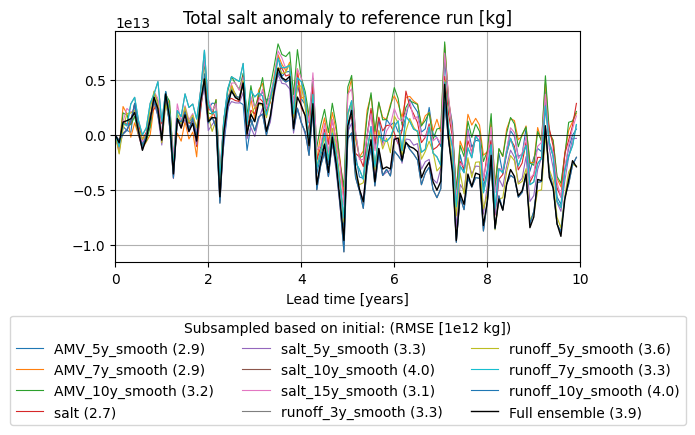

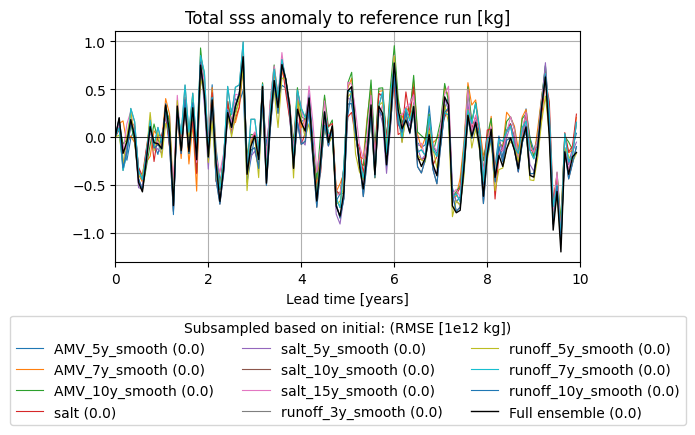

In [ ]:
#data_vars   = ['heat', 'salt', 'sst', 'ssh', 'sss', 'ice']
data_vars   = ['salt', 'sss']
#subset_vars = ['heat', 'salt', 'SST', 'SSS', 'SSH', 'NAO_ND', 'NAO_D', 'NAO_DJF', 'AMV_3y_smooth', 'AMV_5y_smooth', 'AMV_7y_smooth', 'AMV_10y_smooth']
subset_vars = ['AMV_5y_smooth', 'AMV_7y_smooth', 'AMV_10y_smooth', 'salt', 'salt_5y_smooth', 'salt_10y_smooth', 'salt_15y_smooth', 'runoff_3y_smooth', 'runoff_5y_smooth', 'runoff_7y_smooth', 'runoff_10y_smooth']

anomaly_data = {}
for data_var in data_vars:
    subsets_mean = {}
    plt.figure(figsize=(6,3), dpi=100)

    for subset_var in subset_vars:
        subset_years             = eval(f"years_65_{subset_var}_sub")
        mean_data                = eval(f"ds_{data_var}.sel(year=subset_years).mean(dim='year')")
        subsets_mean[subset_var] = mean_data
        key                      = f"{data_var}_{subset_var}"
        anomaly_data[key]        = mean_data - eval(f'refrun_{data_var}')
        plt.plot(np.arange(0,10,1/12), anomaly_data[key], label=f'{subset_var} ({((((anomaly_data[key]**2).mean())**0.5)*1e-12).values:.1f})', lw=0.8)
        
    key = f"{data_var}_ensemble"
    anomaly_data[key] = eval(f'{data_var}_ens_mean') - eval(f'refrun_{data_var}')
    plt.plot(np.arange(0,10,1/12), anomaly_data[key], label=f'Full ensemble ({((((anomaly_data[key]**2).mean())**0.5)*1e-12).values:.1f})', c='k', lw=1)
    plt.axhline(0, c='k', lw=0.5)
    plt.xlim(0,10)
    plt.xlabel('Lead time [years]')
    plt.title(f'Total {data_var} anomaly to reference run [kg]')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, title='Subsampled based on initial: (RMSE [1e12 kg])')
    plt.grid()


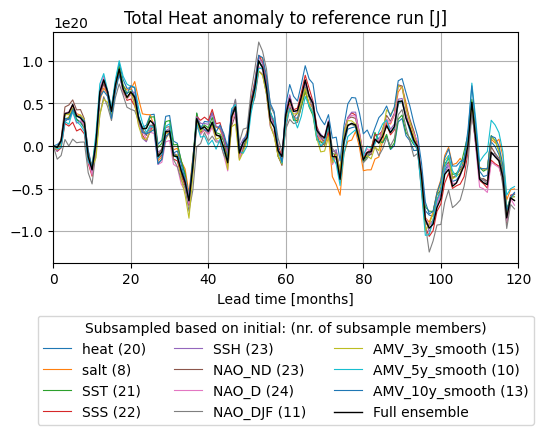

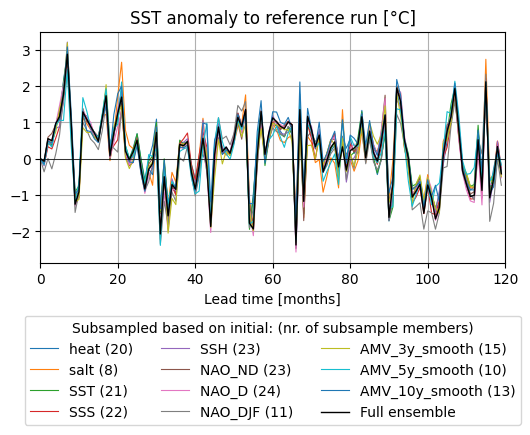

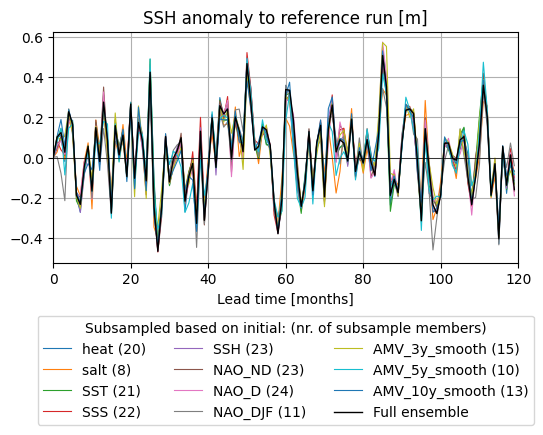

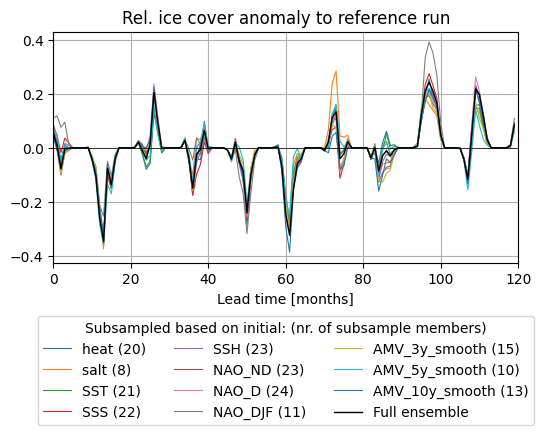

In [ ]:
#data_vars   = ['heat', 'salt', 'sst', 'ssh', 'sss', 'ice']
data_vars   = ['heat', 'sst', 'ssh', 'ice']
#subset_vars = ['heat', 'salt', 'SST', 'SSS', 'SSH', 'NAO_ND', 'NAO_D', 'NAO_DJF', 'AMV_3y_smooth', 'AMV_5y_smooth', 'AMV_7y_smooth', 'AMV_10y_smooth']
subset_vars = ['heat', 'salt', 'SST', 'SSS', 'SSH', 'NAO_ND', 'NAO_D', 'NAO_DJF', 'AMV_3y_smooth', 'AMV_5y_smooth', 'AMV_10y_smooth'] #'AMV_7y_smooth'


for data_var in data_vars:
    subsets_mean = {}
    plt.figure(figsize=(6,3), dpi=100)

    for subset_var in subset_vars:
        subset_years = eval(f"years_65_{subset_var}_sub")
        mean_data = eval(f"ds_{data_var}.sel(year=subset_years).mean(dim='year')")
        subsets_mean[subset_var] = mean_data
        plt.plot((mean_data - eval(f'refrun_{data_var}'))[:120], label=f'{subset_var} ({len(subset_years)})', lw=0.8)

    plt.plot((eval(f'{data_var}_ens_mean') - eval(f'refrun_{data_var}'))[:120], label='Full ensemble', c='k', lw=1)
    plt.axhline(0, c='k', lw=0.5)
    plt.xlim(0,120)
    plt.xlabel('Lead time [months]')
    if data_var == 'heat':
        plt.title(f'Total Heat anomaly to reference run [J]')
    if data_var == 'sst':
        plt.title(f'SST anomaly to reference run [°C]')
    if data_var == 'ssh':
        plt.title(f'SSH anomaly to reference run [m]')
    if data_var == 'ice':
        plt.title(f'Rel. ice cover anomaly to reference run')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, title='Subsampled based on initial: (nr. of subsample members)')
    plt.grid()


### Additional Plots für Vortrag

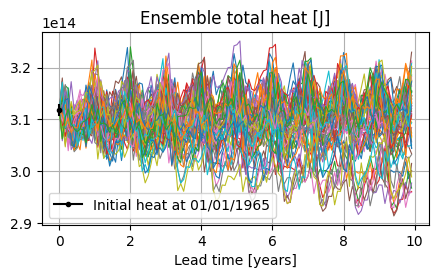

In [ ]:
''' Basic ensemble example plot '''
plt.figure(figsize=(5,2.5),dpi=100)
for year in ds_salt.year:
    plt.plot(np.arange(0,10,1/12),ds_salt.sel(year=year), lw=0.8)
plt.xlabel('Lead time [years]')
plt.grid()
plt.axvline(0, ymin=0.57, ymax=0.622, c='k', lw=1.5, alpha=1)
plt.plot(0, ds_salt.sel(year=1948).sel(month=0), marker='o', c='k', markersize=3, label='Initial heat at 01/01/1965')
plt.legend()
plt.title('Ensemble total heat [J]');

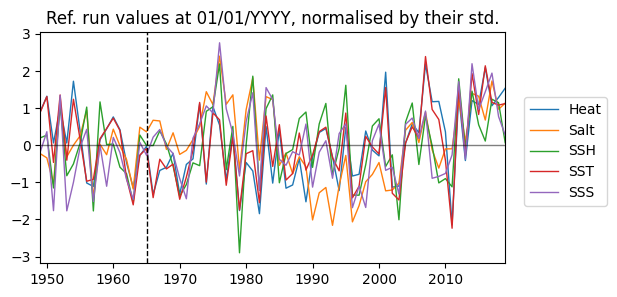

In [ ]:
'''Plot initial field time series for vars, NAO, AMV (20 sec.)'''
# Heat, Salt, SST, SSS, SSH
plt.figure(figsize=(6, 3), dpi=100)
plt.plot(heat_0101.time, (heat_0101 - heat_0101.mean(dim='time'))/(heat_0101.std()), lw=1, label='Heat')
plt.plot(salt_0101.time, (salt_0101 - salt_0101.mean(dim='time'))/(salt_0101.std()), lw=1, label='Salt')
plt.plot(SSH_0101.time, (SSH_0101 - SSH_0101.mean(dim='time'))/(SSH_0101.std()), lw=1, label='SSH')
plt.plot(SST_0101.time, (SST_0101 - SST_0101.mean(dim='time'))/(SST_0101.std()), lw=1, label='SST')
plt.plot(SSS_0101.time, (SSS_0101 - SSS_0101.mean(dim='time'))/(SSS_0101.std()), lw=1, label='SSS')
plt.legend(loc='upper center', bbox_to_anchor=(1.13, 0.75), ncol=1)
plt.title('Ref. run values at 01/01/YYYY, normalised by their std.')
plt.axvline(datetime.datetime(1965, 1, 1), c='k', ls='--', lw=1)
plt.xlim(datetime.datetime(1949, 1, 1), datetime.datetime(2019, 1, 1))
plt.axhline(0, c='k', ls='-', lw=1, alpha=0.5)
# # Past 5/10/15y total salt average
# plt.figure(figsize=(6, 3), dpi=100)
# plt.plot( salt_5y_smooth.time,  (salt_5y_smooth - salt_5y_smooth.mean(dim='time'))/salt_5y_smooth.std(), label='5y smooth')
# plt.plot(salt_10y_smooth.time, (salt_10y_smooth - salt_10y_smooth.mean(dim='time'))/salt_10y_smooth.std(), label='10y smooth')
# plt.plot(salt_15y_smooth.time, (salt_15y_smooth - salt_15y_smooth.mean(dim='time'))/salt_15y_smooth.std(), label='15y smooth')
# plt.axvline(datetime.datetime(1965, 1, 1), c='k', ls='--', lw=1)
# plt.axhline(0, c='k', ls='-', lw=1, alpha=0.5)
# plt.legend()
# plt.title('Ref. run salt, normalised by their std.')
# plt.xlim(datetime.datetime(1950, 1, 1), datetime.datetime(2019, 1, 1));
# # AMV
# plt.figure(figsize=(6, 3), dpi=100)
# plt.plot(ds_AMV['time'], ds_AMV['AMV_index'], alpha=1, label='original')
# plt.plot(ds_AMV['time'], ds_AMV_5y_smooth, alpha=1, label='5y smooth')
# plt.plot(ds_AMV['time'], ds_AMV_10y_smooth, alpha=1, label='10y smooth')
# plt.fill_between(ds_AMV['time'], -AMV_std, AMV_std, color='gray', alpha=0.2, label=r"$\pm 1\sigma$")
# plt.legend()
# plt.title('AMV index')
# plt.axhline(0, c='k', ls='-', lw=1)
# plt.axvline(datetime.datetime(1965, 1, 1), c='k', ls='--', lw=1)
# plt.xlim(datetime.datetime(1950, 1, 1), datetime.datetime(2019, 1, 1))
# # NAO
# plt.figure(figsize=(6, 3), dpi=100)
# plt.plot(ds_NAO_DJF['time'], ds_NAO_DJF['NAO_index'], alpha=1)
# plt.axhline(0, c='k', ls='-', lw=1)
# plt.fill_between(ds_NAO_DJF['time'], -NAO_DJF_std, NAO_DJF_std, color='gray', alpha=0.2, label=r"$\pm 1\sigma$")
# plt.legend()
# plt.title('DJF mean NAO index')
# plt.axvline(datetime.datetime(1965, 1, 1), c='k', ls='--', lw=1)
# plt.xlim(datetime.datetime(1950, 1, 1), datetime.datetime(2019, 1, 1))
# # Example plot for std windows
# plt.figure(figsize=(4,2), dpi=100)
# plt.plot(salt_0101.time, salt_0101/salt_0101.mean(dim='time'), lw=1, c='k')
# std = (salt_0101/salt_0101.mean(dim='time')).std()
# plt.xlim(datetime.datetime(1949, 1, 1), datetime.datetime(2019, 1, 1))
# plt.fill_between(salt_0101.time, 1+1*std,1.1, color='tab:red', alpha=0.5, label='strong pos.')
# plt.fill_between(salt_0101.time, 1+0.5*std,1+1*std, color='tab:red', alpha=0.2, label='moderate pos.')
# plt.fill_between(salt_0101.time, 1-0.5*std,1+0.5*std, color='grey', alpha=0.3, label='neutral')
# plt.fill_between(salt_0101.time, 1-1*std,1-0.5*std, color='tab:blue', alpha=0.2, label='moderate neg.')
# plt.fill_between(salt_0101.time, 0,1-1*std, color='tab:blue', alpha=0.5, label='strong neg.')
# #plt.axhline(1, c='k', ls='-', lw=1)
# sigma_ticks = [1-std, 1-0.5*std, 1+0.5*std, 1+std]
# sigma_labels = ['-σ', '-0.5σ', '0.5σ', 'σ']
# plt.yticks(sigma_ticks, sigma_labels)
# plt.xticks([]);
# plt.ylim(0.95,1.052)
# plt.legend(loc='upper center', bbox_to_anchor=(1.3, 0.885), ncol=1);

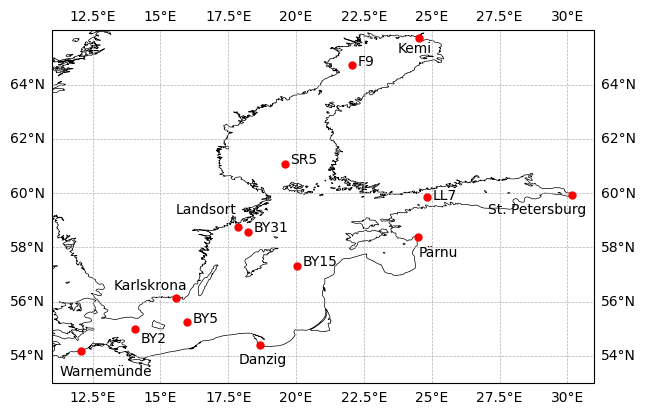

In [ ]:
'''Plot map of evaluated stations'''
# Dictionary of stations with latitudes and longitudes
stations = { 
    "BY5" : {"lat": 55.25, "lon": 15.98},
    "F9"  : {"lat": 64.71, "lon": 22.07},
    "SR5" : {"lat": 61.08, "lon": 19.58},
    "BY31": {"lat": 58.58, "lon": 18.23},
    "BY15": {"lat": 57.33, "lon": 20.05},
    "LL7" : {"lat": 59.85, "lon": 24.84},
    "BY2" : {"lat": 55.00, "lon": 14.08}
}

stations_coast = {
    "Warnemünde"     : {"lat": 54.18, "lon": 12.08},
    "Danzig"         : {"lat": 54.41, "lon": 18.67},
    "Karlskrona"     : {"lat": 56.15, "lon": 15.58},
    "St. Petersburg" : {"lat": 59.94, "lon": 30.18},
    "Landsort"       : {"lat": 58.74, "lon": 17.87},
    "Kemi"           : {"lat": 65.73, "lon": 24.55},
    "Pärnu"          : {"lat": 58.37, "lon": 24.50}
}

# Create the figure and axis with a specific projection
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()}, dpi=100, figsize=(7,7))
ax.set_extent([11, 31, 53, 66], crs=ccrs.PlateCarree())  # Baltic Sea region
# Add coastlines and gridlines
ax.coastlines(lw=0.5)
ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5)

# Plot each station in water
for station, coords in stations.items():
    if station == "BY2":
        ax.plot(coords['lon'], coords['lat'], marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
        ax.text(coords['lon'] + 0.2, coords['lat'] - 0.5, station, transform=ccrs.PlateCarree(), fontsize=10, alpha=1)
    elif station == "LL7":
        ax.plot(coords['lon'], coords['lat'], marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
        ax.text(coords['lon'] + 0.2, coords['lat'] - 0.1, station, transform=ccrs.PlateCarree(), fontsize=10, alpha=1)
    else:        
        ax.plot(coords['lon'], coords['lat'], marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
        ax.text(coords['lon'] + 0.2, coords['lat'], station, transform=ccrs.PlateCarree(), fontsize=10, alpha=1)

for station, coords in stations_coast.items():
    if station == "Landsort":
        ax.plot(coords['lon'], coords['lat'], marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
        ax.text(coords['lon'] -2.3, coords['lat'] +0.5, station, transform=ccrs.PlateCarree(), fontsize=10, alpha=1)
    elif station == "Warnemünde":
        ax.plot(coords['lon'], coords['lat'], marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
        ax.text(coords['lon'] - 0.8, coords['lat'] -0.9, station, transform=ccrs.PlateCarree(), fontsize=10, alpha=1)
    elif station == "Karlskrona":
        ax.plot(coords['lon'], coords['lat'], marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
        ax.text(coords['lon'] - 2.3, coords['lat'] + 0.3, station, transform=ccrs.PlateCarree(), fontsize=10, alpha=1)
    elif station == "Kemi":
        ax.plot(coords['lon'], coords['lat'], marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
        ax.text(coords['lon'] - 0.8, coords['lat'] -0.55, station, transform=ccrs.PlateCarree(), fontsize=10, alpha=1)
    elif station == "St. Petersburg":
        ax.plot(coords['lon'], coords['lat'], marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
        ax.text(coords['lon'] - 3.1, coords['lat'] + -0.7, station, transform=ccrs.PlateCarree(), fontsize=10, alpha=1)
    elif station == "Pärnu":
        ax.plot(coords['lon'], coords['lat'], marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
        ax.text(coords['lon'], coords['lat'] + -0.7, station, transform=ccrs.PlateCarree(), fontsize=10, alpha=1)
    else:  
        ax.plot(coords['lon'], coords['lat'], marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
        ax.text(coords['lon'] - 0.8, coords['lat'] - 0.7, station, transform=ccrs.PlateCarree(), fontsize=10, alpha=1)        


### Stations

In [ ]:
'''Read in ds with stations data'''

stations_list = ['BY02', 'BY05', 'BY15', 'BY31', 'SR5', 'F9', 'LL7']
datasets = []

# Read in all .nc files as xr.Dataset
for station in stations_list:
    file_pattern = f"../testrun_with_oxygen/member_65_1948/member_65_1948_194*/194*0101.station_{station}.nc.*"
    ds = xr.open_mfdataset(file_pattern, combine='nested', concat_dim='time')
    ds = ds.expand_dims({'station': [station]})  # Add station as a new dimension
    ds = ds.squeeze(dim=("xh_sub01", "yh_sub01"), drop=True)
    ds = ds.drop_vars(["nv", "z_i", "average_T1", "average_T2", "average_DT", "time_bnds"])  # Remove unwanted stuff
    ds = ds.where(ds.notnull().compute(), drop=True)  # Remove nan values - for every station below the sea bottom at that point the grid goes on
    datasets.append(ds)
stations_ds = xr.concat(datasets, dim='station')

print(stations_ds)

<xarray.Dataset> Size: 384kB
Dimensions:  (station: 7, time: 24, z_l: 95)
Coordinates:
  * z_l      (z_l) float64 760B 0.4367 1.323 2.221 3.145 ... 202.8 206.3 209.9
  * time     (time) object 192B 1948-01-16 12:00:00 ... 1949-12-16 12:00:00
  * station  (station) object 56B 'BY02' 'BY05' 'BY15' 'BY31' 'SR5' 'F9' 'LL7'
Data variables:
    h        (station, time, z_l) float64 128kB dask.array<chunksize=(1, 12, 34), meta=np.ndarray>
    temp     (station, time, z_l) float64 128kB dask.array<chunksize=(1, 12, 34), meta=np.ndarray>
    salt     (station, time, z_l) float64 128kB dask.array<chunksize=(1, 12, 34), meta=np.ndarray>
Attributes:
    NumFilesInSet:  0
    title:          MOM6 Baltic 8nm with oxygen tracer
    grid_type:      regular
    grid_tile:      N/A


In [ ]:
test = xr.open_dataset("../testrun_with_oxygen/member_65_1948/member_65_1948_1948/19480101.station_BY02.nc.0010")
print(test)

<xarray.Dataset> Size: 31kB
Dimensions:     (xh_sub01: 1, yh_sub01: 1, z_l: 100, z_i: 101, time: 12, nv: 2)
Coordinates:
  * xh_sub01    (xh_sub01) float64 8B 14.12
  * yh_sub01    (yh_sub01) float64 8B 54.96
  * z_l         (z_l) float64 800B 0.4367 1.323 2.221 ... 220.7 224.4 228.1
  * z_i         (z_i) float64 808B 0.0 0.8735 1.772 2.67 ... 222.6 226.3 230.0
  * time        (time) object 96B 1948-01-16 12:00:00 ... 1948-12-16 12:00:00
  * nv          (nv) float64 16B 1.0 2.0
Data variables:
    h           (time, z_l, yh_sub01, xh_sub01) float64 10kB ...
    temp        (time, z_l, yh_sub01, xh_sub01) float64 10kB ...
    salt        (time, z_l, yh_sub01, xh_sub01) float64 10kB ...
    average_T1  (time) datetime64[ns] 96B ...
    average_T2  (time) datetime64[ns] 96B ...
    average_DT  (time) timedelta64[ns] 96B ...
    time_bnds   (time, nv) object 192B ...
Attributes:
    NumFilesInSet:  0
    title:          MOM6 Baltic 8nm with oxygen tracer
    grid_type:      regular
    gri

### Archive: Ensemble intro plots

In [ ]:
'''Calculate anomalies to climatology - maybe not needed'''
# Compute ensemble climatology ('cycle') and anomaly to it
sst_ens_anom, sst_cycle = remove_annual_cycle_mo(sst_ens_mean)
sst_cycle               = xr.concat([xr.DataArray([SST_init], coords={'month': [0]}, dims=['month']) , sst_cycle], dim='month').sortby('month')  # add initial value for month=0
sss_ens_anom, sss_cycle = remove_annual_cycle_mo(sss_ens_mean)
sss_cycle               = xr.concat([xr.DataArray([SSS_init], coords={'month': [0]}, dims=['month']) , sss_cycle], dim='month').sortby('month')  # add initial value for month=0
ssh_ens_anom, ssh_cycle = remove_annual_cycle_mo(ssh_ens_mean)
ssh_cycle               = xr.concat([xr.DataArray([SSH_init], coords={'month': [0]}, dims=['month']) , ssh_cycle], dim='month').sortby('month')  # add initial value for month=0
ice_ens_anom, ice_cycle = remove_annual_cycle_mo(ice_ens_mean)  # no initial value
salt_ens_anom, salt_cycle = remove_annual_cycle_mo(salt_ens_mean)
salt_cycle                = xr.concat([xr.DataArray([salt_init], coords={'month': [0]}, dims=['month']) , salt_cycle], dim='month').sortby('month')  # add initial value for month=0
heat_ens_anom, heat_cycle = remove_annual_cycle_mo(heat_ens_mean)
heat_cycle                = xr.concat([xr.DataArray([heat_init], coords={'month': [0]}, dims=['month']) , heat_cycle], dim='month').sortby('month')  # add initial value for month=0
# Calculate anomlies for only the first year for better plotting
plot_sst_1y_anom     = (ds_sst.sel(month=slice(0, 12)) - sst_cycle).compute()
plot_sst_ens_1y_anom = (sst_ens_anom.sel(month=slice(0, 12))).compute()
plot_sss_1y_anom     = (ds_sss.sel(month=slice(0, 12)) - sss_cycle).compute()
plot_sss_ens_1y_anom = (sss_ens_anom.sel(month=slice(0, 12))).compute()
plot_ssh_1y_anom     = (ds_ssh.sel(month=slice(0, 12)) - ssh_cycle).compute()
plot_ssh_ens_1y_anom = (ssh_ens_anom.sel(month=slice(0, 12))).compute()
plot_ice_1y_anom          = (ds_ice.sel(month=slice(0, 12)) - ice_cycle).compute()
plot_ice_ens_1y_anom      = (ice_ens_anom.sel(month=slice(0, 12))).compute()
plot_ice_1y_anom     = xr.DataArray(np.insert(ice_1y_anom.values, 0, 0, axis=1), coords=[ice_1y_anom.year.values, np.insert(ice_1y_anom.month.values, 0, 0)], dims=["year", "month"]).compute()
plot_ice_ens_1y_anom = xr.DataArray(np.insert(ice_ens_1y_anom.values, 0, 0), coords=[np.insert(ice_ens_1y_anom.month.values, 0, 0)], dims=["month"]).compute()
plot_salt_1y_anom     = (ds_salt.sel(month=slice(0, 12)) - salt_cycle).compute()
plot_salt_ens_1y_anom = (salt_ens_anom.sel(month=slice(0, 12))).compute()
plot_heat_1y_anom     = (ds_heat.sel(month=slice(0, 12)) - heat_cycle).compute()
plot_heat_ens_1y_anom = (heat_ens_anom.sel(month=slice(0, 12))).compute()
# Compute anomalies from climatology for sss and total salt for whole 10y, not only 1y as above
sss_anom  = {}
salt_anom = {}
for year in range(1948,2011):
    sss_anom[year], _  = remove_annual_cycle_mo(ds_sss.sel(year=year).drop_vars("year"))
    salt_anom[year], _ = remove_annual_cycle_mo(ds_salt.sel(year=year).drop_vars("year"))  # drop year coordinate to make transformation concatenation easier
plot_sss_anom      = (xr.Dataset(sss_anom).to_array(dim='year')).compute()
plot_salt_anom     = (xr.Dataset(salt_anom).to_array(dim='year')).compute()
plot_sss_ens_anom  = sss_ens_anom.compute()
plot_salt_ens_anom = salt_ens_anom.compute();

NameError: name 'ice_1y_anom' is not defined

In [ ]:
'''Calculate & compute anomalies to ens. mean & refrun'''
plot_values_heat_ens = {}
plot_values_heat_ref = {}
for i in [5, 15, 30, 45, 63]:
    random_years = random.sample(ds_heat.year.values.tolist(), i) 
    subset = ds_heat.sel(year=random_years)
    plot_values_heat_ens[i] = subset.mean(dim='year') - heat_ens_mean  # Anomaly to ensemble mean
    plot_values_heat_ref[i] = subset.mean(dim='year') - refrun_heat   # Anomaly to refrun
plot_values_heat_ens = xr.Dataset(plot_values_heat_ens).to_array(dim='member_nr').compute()
plot_values_heat_ref = xr.Dataset(plot_values_heat_ref).to_array(dim='member_nr').compute()

plot_values_salt_ens = {}
plot_values_salt_ref = {}
for i in [5, 15, 30, 45, 63]:
    random_years = random.sample(ds_salt.year.values.tolist(), i) 
    subset = ds_salt.sel(year=random_years)
    plot_values_salt_ens[i] = subset.mean(dim='year') - salt_ens_mean  # Anomaly to ensemble mean
    plot_values_salt_ref[i] = subset.mean(dim='year') - refrun_salt   # Anomaly to refrun
plot_values_salt_ens = xr.Dataset(plot_values_salt_ens).to_array(dim='member_nr').compute()
plot_values_salt_ref = xr.Dataset(plot_values_salt_ref).to_array(dim='member_nr').compute()

plot_values_sss_ens = {}
plot_values_sss_ref = {}
for i in [5, 15, 30, 45, 63]:
    random_years = random.sample(ds_sss.year.values.tolist(), i) 
    subset = ds_sss.sel(year=random_years)
    plot_values_sss_ens[i] = subset.mean(dim='year') - sss_ens_mean  # Anomaly to ensemble mean
    plot_values_sss_ref[i] = subset.mean(dim='year') - refrun_sss   # Anomaly to refrun
plot_values_sss_ens = xr.Dataset(plot_values_sss_ens).to_array(dim='member_nr').compute()
plot_values_sss_ref = xr.Dataset(plot_values_sss_ref).to_array(dim='member_nr').compute()

plot_values_sst_ens = {}
plot_values_sst_ref = {}
for i in [5, 15, 30, 45, 63]:
    random_years = random.sample(ds_sst.year.values.tolist(), i) 
    subset = ds_sst.sel(year=random_years)
    plot_values_sst_ens[i] = subset.mean(dim='year') - sst_ens_mean  # Anomaly to ensemble mean
    plot_values_sst_ref[i] = subset.mean(dim='year') - refrun_sst   # Anomaly to refrun
plot_values_sst_ens = xr.Dataset(plot_values_sst_ens).to_array(dim='member_nr').compute()
plot_values_sst_ref = xr.Dataset(plot_values_sst_ref).to_array(dim='member_nr').compute()

plot_values_ssh_ens = {}
plot_values_ssh_ref = {}
for i in [5, 15, 30, 45, 63]:
    random_years = random.sample(ds_ssh.year.values.tolist(), i) 
    subset = ds_ssh.sel(year=random_years)
    plot_values_ssh_ens[i] = subset.mean(dim='year') - ssh_ens_mean  # Anomaly to ensemble mean
    plot_values_ssh_ref[i] = subset.mean(dim='year') - refrun_ssh   # Anomaly to refrun
plot_values_ssh_ens = xr.Dataset(plot_values_ssh_ens).to_array(dim='member_nr').compute()
plot_values_ssh_ref = xr.Dataset(plot_values_ssh_ref).to_array(dim='member_nr').compute()

plot_values_ice_ens = {}
plot_values_ice_ref = {}
for i in [5, 15, 30, 45, 63]:
    random_years = random.sample(ds_ice.year.values.tolist(), i) 
    subset = ds_ice.sel(year=random_years)
    plot_values_ice_ens[i] = subset.mean(dim='year') - ice_ens_mean  # Anomaly to ensemble mean
    plot_values_ice_ref[i] = subset.mean(dim='year') - refrun_ice   # Anomaly to refrun
plot_values_ice_ens = xr.Dataset(plot_values_ice_ens).to_array(dim='member_nr').compute()
plot_values_ice_ref = xr.Dataset(plot_values_ice_ref).to_array(dim='member_nr').compute()

In [ ]:
'''Define x-axes'''
# Some time series have 120, some 121 values, so different x-axes are needed
x_axis_120 = np.arange(0,10,1/12)
x_axis_121 = np.linspace(0,10,121)

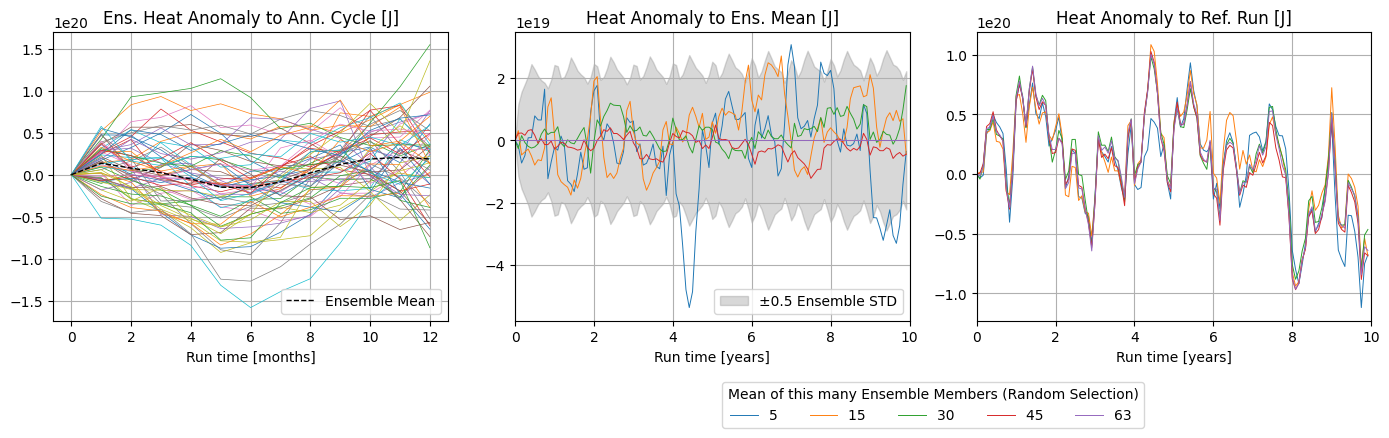

In [ ]:
'''Plot heat'''
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

for year in plot_heat_1y_anom.year.values:
    ax[0].plot(range(13), plot_heat_1y_anom.sel(year=year), linewidth=0.5)
ax[0].plot(range(13), plot_heat_ens_1y_anom, color='k', linewidth=1, alpha=1, ls='--', label='Ensemble Mean')
ax[0].set_xlabel('Run time [months]')
ax[0].set_title('Ens. Heat Anomaly to Ann. Cycle [J]')
ax[0].legend(loc='lower right', ncol=1)
ax[0].grid()

for i in [5, 15, 30, 45, 63]:
    ax[1].plot(x_axis_120, plot_values_heat_ens.sel(member_nr=i), label=f'{i} ', linewidth=0.7)
    ax[2].plot(x_axis_120, plot_values_heat_ref.sel(member_nr=i), label=f'{i} ', linewidth=0.7)
ax[1].set_xlim(0, 10)
ax[1].set_xlabel('Run time [years]')
ax[1].set_title('Heat Anomaly to Ens. Mean [J]')
ax[1].grid()
ax[1].fill_between(x_axis_120, -0.5*heat_ens_std, 0.5*heat_ens_std, color='gray', alpha=0.3, label="±0.5 Ensemble STD")
handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend([handles[-1]], [labels[-1]])

ax[2].set_xlim(0, 10)
ax[2].set_xlabel('Run time [years]')
ax[2].set_title('Heat Anomaly to Ref. Run [J]')
ax[2].grid()

handles, labels = ax[2].get_legend_handles_labels()
fig.legend(handles, labels, title="Mean of this many Ensemble Members (Random Selection)", loc='upper center', bbox_to_anchor=(0.67, 0.01), ncol=5)
plt.tight_layout()
plt.show()

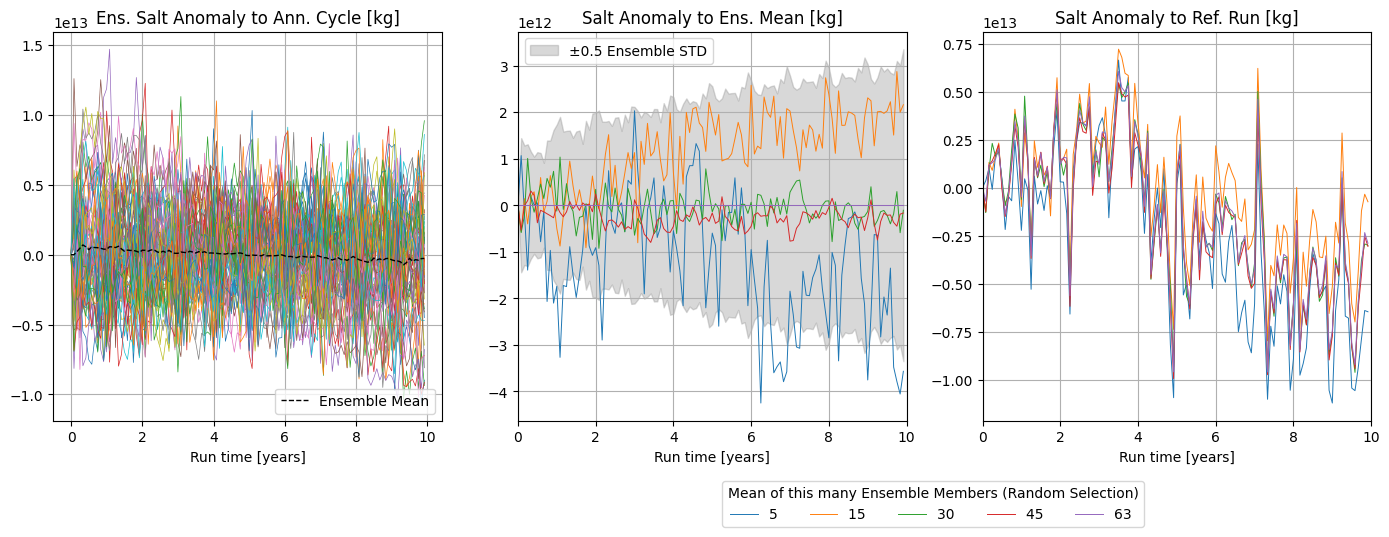

In [ ]:
'''Plot salt'''
fig, ax = plt.subplots(1, 3, figsize=(14, 5))

for year in plot_salt_anom.year.values:
    ax[0].plot(x_axis_120, plot_salt_anom.sel(year=year), linewidth=0.5)
ax[0].plot(x_axis_120, plot_salt_ens_anom, color='k', linewidth=1, alpha=1, ls='--', label='Ensemble Mean')
ax[0].set_xlabel('Run time [years]')
ax[0].set_title('Ens. Salt Anomaly to Ann. Cycle [kg]')
ax[0].legend(loc='lower right', ncol=1)
ax[0].grid()

for i in [5, 15, 30, 45, 63]:
    ax[1].plot(x_axis_120, plot_values_salt_ens.sel(member_nr=i), label=f'{i} ', linewidth=0.7)
    ax[2].plot(x_axis_120, plot_values_salt_ref.sel(member_nr=i), label=f'{i} ', linewidth=0.7)
ax[1].set_xlim(0, 10)
ax[1].set_xlabel('Run time [years]')
ax[1].set_title('Salt Anomaly to Ens. Mean [kg]')
ax[1].grid()
ax[1].fill_between(x_axis_120, -0.5*salt_ens_std, 0.5*salt_ens_std, color='gray', alpha=0.3, label="±0.5 Ensemble STD")
handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend([handles[-1]], [labels[-1]])

ax[2].set_xlim(0, 10)
ax[2].set_xlabel('Run time [years]')
ax[2].set_title('Salt Anomaly to Ref. Run [kg]')
ax[2].grid()

handles, labels = ax[2].get_legend_handles_labels()
fig.legend(handles, labels, title="Mean of this many Ensemble Members (Random Selection)", loc='upper center', bbox_to_anchor=(0.67, 0.01), ncol=5)
plt.tight_layout()
plt.show()

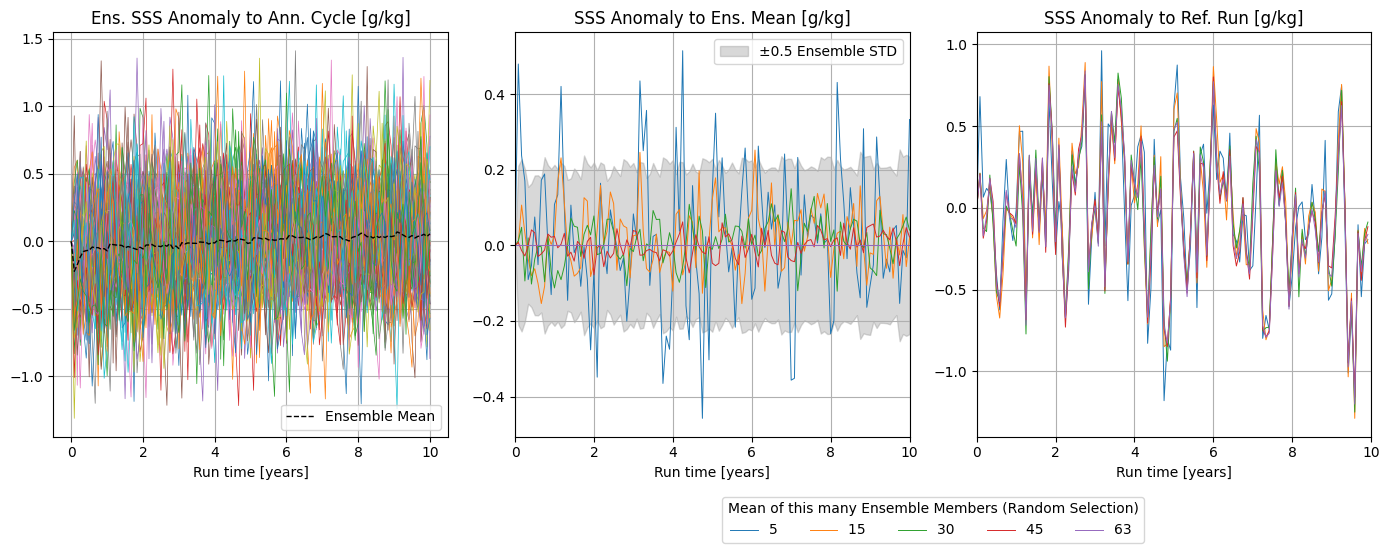

In [ ]:
'''Plot sss'''
fig, ax = plt.subplots(1, 3, figsize=(14, 5))

for year in plot_sss_anom.year.values:
    ax[0].plot(x_axis_121, plot_sss_anom.sel(year=year), linewidth=0.5)
ax[0].plot(x_axis_121, plot_sss_ens_anom, color='k', linewidth=1, alpha=1, ls='--', label='Ensemble Mean')
ax[0].set_xlabel('Run time [years]')
ax[0].set_title('Ens. SSS Anomaly to Ann. Cycle [g/kg]')
ax[0].legend(loc='lower right', ncol=1)
ax[0].grid()

for i in [5, 15, 30, 45, 63]:
    ax[1].plot(x_axis_121, plot_values_sss_ens.sel(member_nr=i), label=f'{i} ', linewidth=0.7)
    ax[2].plot(x_axis_120, plot_values_sss_ref.sel(member_nr=i), label=f'{i} ', linewidth=0.7)
ax[1].set_xlim(0, 10)
ax[1].set_xlabel('Run time [years]')
ax[1].set_title('SSS Anomaly to Ens. Mean [g/kg]')
ax[1].grid()
ax[1].fill_between(x_axis_121, -0.5*sss_ens_std, 0.5*sss_ens_std, color='gray', alpha=0.3, label="±0.5 Ensemble STD")
handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend([handles[-1]], [labels[-1]])

ax[2].set_xlim(0, 10)
ax[2].set_xlabel('Run time [years]')
ax[2].set_title('SSS Anomaly to Ref. Run [g/kg]')
ax[2].grid()

handles, labels = ax[2].get_legend_handles_labels()
fig.legend(handles, labels, title="Mean of this many Ensemble Members (Random Selection)", loc='upper center', bbox_to_anchor=(0.67, 0.01), ncol=5)
plt.tight_layout()
plt.show()

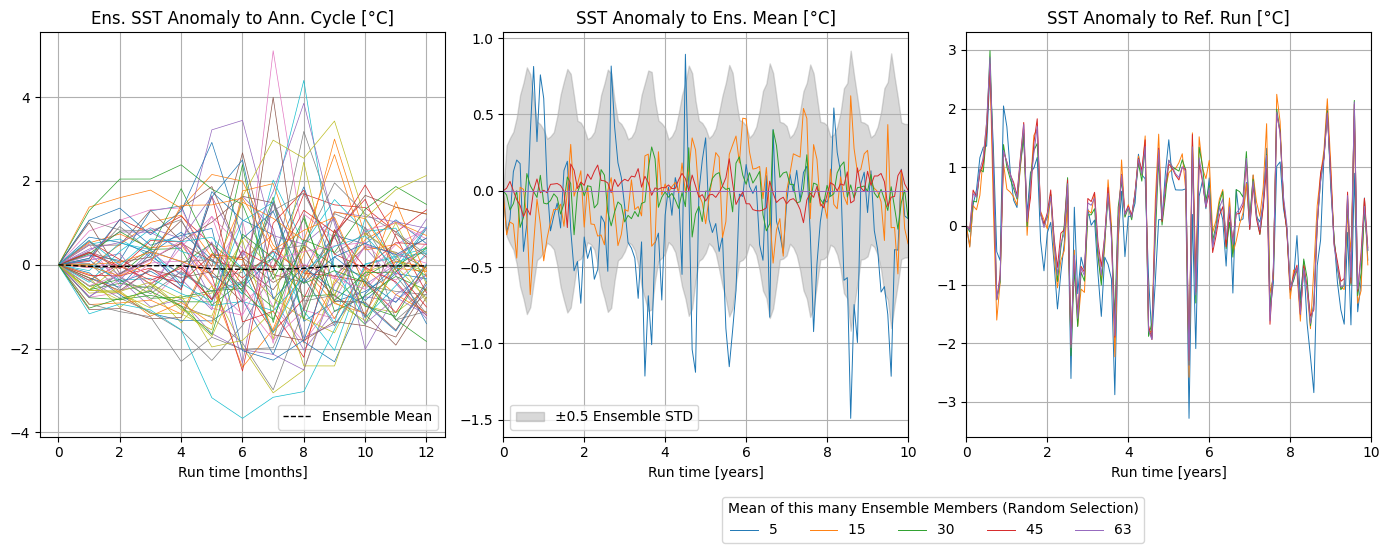

In [ ]:
'''Plot sst'''
fig, ax = plt.subplots(1, 3, figsize=(14, 5))

for year in plot_sst_1y_anom.year.values:
    ax[0].plot(range(13), plot_sst_1y_anom.sel(year=year), linewidth=0.5)
ax[0].plot(range(13), plot_sst_ens_1y_anom, color='k', linewidth=1, alpha=1, ls='--', label='Ensemble Mean')
ax[0].set_xlabel('Run time [months]')
ax[0].set_title('Ens. SST Anomaly to Ann. Cycle [°C]')
ax[0].legend(loc='lower right', ncol=1)
ax[0].grid()

for i in [5, 15, 30, 45, 63]:
    ax[1].plot(x_axis_121, plot_values_sst_ens.sel(member_nr=i), label=f'{i} ', linewidth=0.7)
    ax[2].plot(x_axis_120, plot_values_sst_ref.sel(member_nr=i), label=f'{i} ', linewidth=0.7)
ax[1].set_xlim(0, 10)
ax[1].set_xlabel('Run time [years]')
ax[1].set_title('SST Anomaly to Ens. Mean [°C]')
ax[1].grid()
ax[1].fill_between(x_axis_121, -0.5*sst_ens_std, 0.5*sst_ens_std, color='gray', alpha=0.3, label="±0.5 Ensemble STD")
handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend([handles[-1]], [labels[-1]])

ax[2].set_xlim(0, 10)
ax[2].set_xlabel('Run time [years]')
ax[2].set_title('SST Anomaly to Ref. Run [°C]')
ax[2].grid()

handles, labels = ax[2].get_legend_handles_labels()
fig.legend(handles, labels, title="Mean of this many Ensemble Members (Random Selection)", loc='upper center', bbox_to_anchor=(0.67, 0.01), ncol=5)
plt.tight_layout()
plt.show()

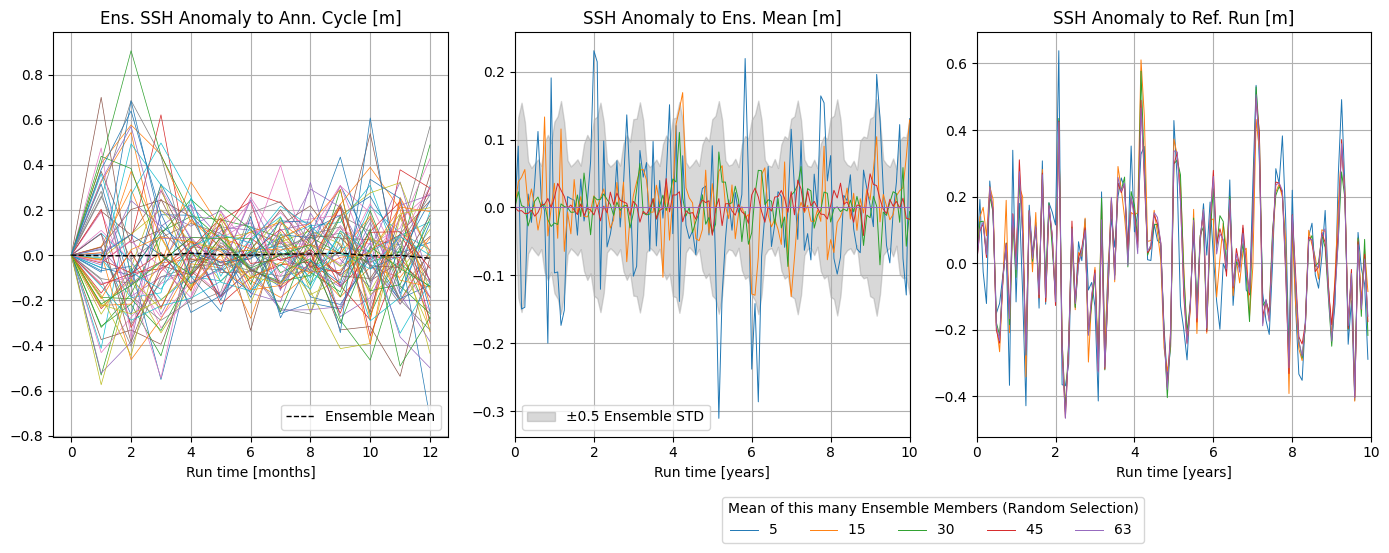

In [ ]:
'''Plot ssh'''
fig, ax = plt.subplots(1, 3, figsize=(14, 5))

for year in plot_ssh_1y_anom.year.values:
    ax[0].plot(range(13), plot_ssh_1y_anom.sel(year=year), linewidth=0.5)
ax[0].plot(range(13), plot_ssh_ens_1y_anom, color='k', linewidth=1, alpha=1, ls='--', label='Ensemble Mean')
ax[0].set_xlabel('Run time [months]')
ax[0].set_title('Ens. SSH Anomaly to Ann. Cycle [m]')
ax[0].legend(loc='lower right', ncol=1)
ax[0].grid()

for i in [5, 15, 30, 45, 63]:
    ax[1].plot(x_axis_121, plot_values_ssh_ens.sel(member_nr=i), label=f'{i} ', linewidth=0.7)
    ax[2].plot(x_axis_120, plot_values_ssh_ref.sel(member_nr=i), label=f'{i} ', linewidth=0.7)
ax[1].set_xlim(0, 10)
ax[1].set_xlabel('Run time [years]')
ax[1].set_title('SSH Anomaly to Ens. Mean [m]')
ax[1].grid()
ax[1].fill_between(x_axis_121, -0.5*ssh_ens_std, 0.5*ssh_ens_std, color='gray', alpha=0.3, label="±0.5 Ensemble STD")
handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend([handles[-1]], [labels[-1]])

ax[2].set_xlim(0, 10)
ax[2].set_xlabel('Run time [years]')
ax[2].set_title('SSH Anomaly to Ref. Run [m]')
ax[2].grid()

handles, labels = ax[2].get_legend_handles_labels()
fig.legend(handles, labels, title="Mean of this many Ensemble Members (Random Selection)", loc='upper center', bbox_to_anchor=(0.67, 0.01), ncol=5)
plt.tight_layout()
plt.show()

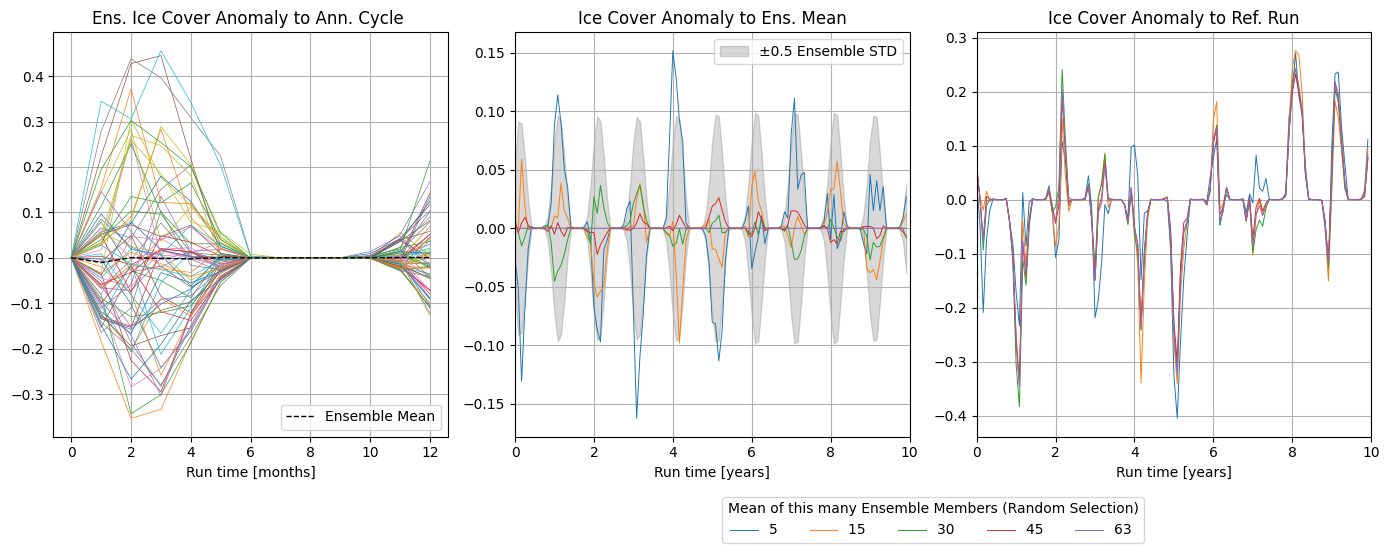

In [ ]:
'''Plot ice'''
fig, ax = plt.subplots(1, 3, figsize=(14, 5))

for year in plot_ice_1y_anom.year.values:
    ax[0].plot(plot_ice_1y_anom.sel(year=year), linewidth=0.5)
ax[0].plot(plot_ice_ens_1y_anom, color='k', linewidth=1, alpha=1, ls='--', label='Ensemble Mean')
ax[0].set_xlabel('Run time [months]')
ax[0].set_title('Ens. Ice Cover Anomaly to Ann. Cycle ')
ax[0].legend(loc='lower right', ncol=1)
ax[0].grid()

for i in [5, 15, 30, 45, 63]:
    ax[1].plot(x_axis_120, plot_values_ice_ens.sel(member_nr=i), label=f'{i} ', linewidth=0.7)
    ax[2].plot(x_axis_120, plot_values_ice_ref.sel(member_nr=i), label=f'{i} ', linewidth=0.7)
ax[1].set_xlim(0, 10)
ax[1].set_xlabel('Run time [years]')
ax[1].set_title('Ice Cover Anomaly to Ens. Mean')
ax[1].grid()
ax[1].fill_between(x_axis_120, -0.5*ice_ens_std, 0.5*ice_ens_std, color='gray', alpha=0.3, label="±0.5 Ensemble STD")
handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend([handles[-1]], [labels[-1]])

ax[2].set_xlim(0, 10)
ax[2].set_xlabel('Run time [years]')
ax[2].set_title('Ice Cover Anomaly to Ref. Run')
ax[2].grid()

handles, labels = ax[2].get_legend_handles_labels()
fig.legend(handles, labels, title="Mean of this many Ensemble Members (Random Selection)", loc='upper center', bbox_to_anchor=(0.67, 0.01), ncol=5)
plt.tight_layout()
plt.show()

### Archive: Ensemble error convergence

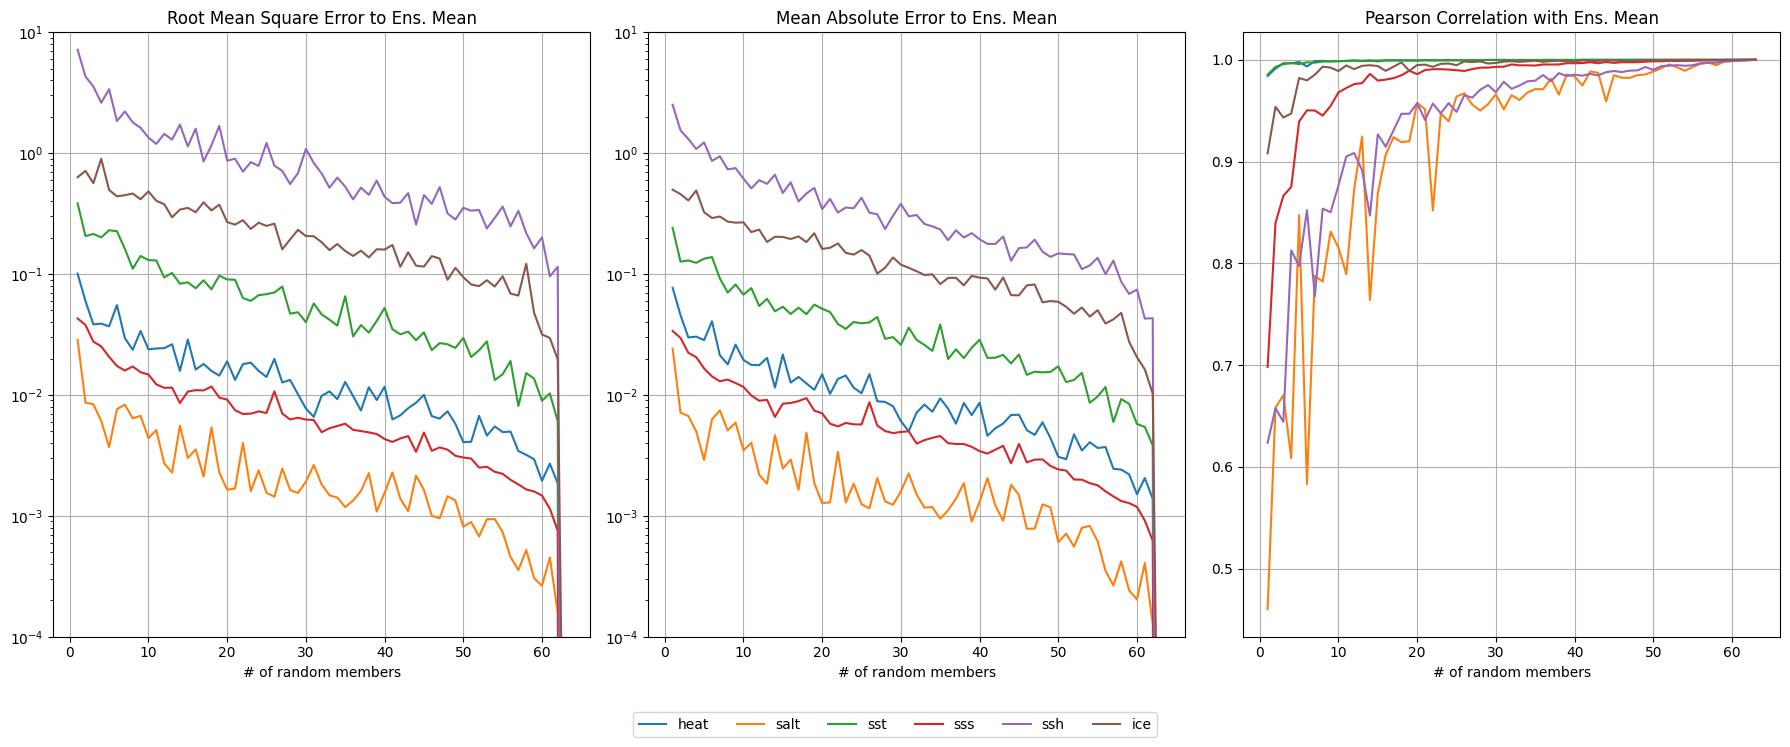

In [ ]:
''' Ensemble error convergence'''
rmse_heat, mae_heat, corr_heat = get_errors(ds_heat, heat_ens_mean)
rmse_salt, mae_salt, corr_salt = get_errors(ds_salt, salt_ens_mean)
rmse_sst, mae_sst, corr_sst    = get_errors(ds_sst, sst_ens_mean)
rmse_sss, mae_sss, corr_sss    = get_errors(ds_sss, sss_ens_mean)
rmse_ssh, mae_ssh, corr_ssh    = get_errors(ds_ssh, ssh_ens_mean)
rmse_ice, mae_ice, corr_ice    = get_errors(ds_ice, ice_ens_mean)

fig, ax = plt.subplots(1, 3, figsize=(18, 7))
x = range(1,64)

ax[0].plot(x, rmse_heat, label='heat')
ax[0].plot(x, rmse_salt, label='salt')
ax[0].plot(x, rmse_sst, label='sst')
ax[0].plot(x, rmse_sss, label='sss')
ax[0].plot(x, rmse_ssh, label='ssh')
ax[0].plot(x, rmse_ice, label='ice')
ax[0].set_ylim(0.0001, 10)
ax[0].set_yscale('log')
ax[0].set_xlabel('# of random members')
ax[0].set_title('Root Mean Square Error to Ens. Mean')
ax[0].grid()

ax[1].plot(x, mae_heat, label='heat')
ax[1].plot(x, mae_salt, label='salt')
ax[1].plot(x, mae_sst, label='sst')
ax[1].plot(x, mae_sss, label='sss')
ax[1].plot(x, mae_ssh, label='ssh')
ax[1].plot(x, mae_ice, label='ice')
ax[1].set_ylim(0.0001, 10)
ax[1].set_yscale('log')
ax[1].set_xlabel('# of random members')
ax[1].set_title('Mean Absolute Error to Ens. Mean')
ax[1].grid()

ax[2].plot(x, corr_heat, label='heat')
ax[2].plot(x, corr_salt, label='salt')
ax[2].plot(x, corr_sst, label='sst')
ax[2].plot(x, corr_sss, label='sss')
ax[2].plot(x, corr_ssh, label='ssh')
ax[2].plot(x, corr_ice, label='ice')
#ax[2].set_ylim(0.3, 1)
#ax[2].set_xscale('log')
ax[2].set_xlabel('# of random members')
ax[2].set_title('Pearson Correlation with Ens. Mean')
ax[2].grid()

fig.legend(['heat', 'salt', 'sst', 'sss', 'ssh', 'ice'], loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.07))
plt.tight_layout()
plt.show()


### Archive: Autocorrelation stuff

In [ ]:
# # Compute autocorrelation function of a given dataset
# def autocorrelation(ds,steps):
#     # ds - time series dataarray

#     if isinstance(ds, xr.DataArray):
#         time_series = ds.values[~np.isnan(ds.values)]  # remove nan values
#     else:
#         time_series = ds
    
#     # At first substract the linear trend from the time series
#     #time_index = np.arange(0,len(time_series),1)
#     #slope, intercept, _, _, _ = linregress(time_index, time_series)
#     #trend = slope * time_index + intercept
#     #time_series = time_series - trend

#     autocorr = []
#     for i in range (1,int(steps)+1):
#         print(i)
#         autocorr = np.append(autocorr, np.corrcoef(time_series[:-i], time_series[i:])[0, 1])
#     return autocorr

In [ ]:
# # Look at autocorrrelation
# sss_anom, sss_annual_cycle = remove_annual_cycle_mo(sss_ens_mean)
# # ac_test = autocorrelation(test,110)
# # plt.figure()
# # plt.plot(ac_test)
# # plt.xlabel('Time lag (months)')
# # plt.ylabel('Autocorrelation')
# # plt.title('Sea surface salinity')
# ssh_anom, ssh_annual_cycle = remove_annual_cycle_mo(ssh_ens_mean)
# # ac_test = autocorrelation(test,110)
# # plt.figure()
# # plt.plot(ac_test)
# # plt.xlabel('Time lag (months)')
# # plt.ylabel('Autocorrelation')
# # plt.title('Sea surface height')
# sst_anom, sst_annual_cycle = remove_annual_cycle_mo(sst_ens_mean)
# # ac_test = autocorrelation(test,110)
# # plt.figure()
# # plt.plot(ac_test)
# # plt.xlabel('Time lag (months)')
# # plt.ylabel('Autocorrelation')
# # plt.title('Sea surface temprature')
# ice_anom, ice_annual_cycle = remove_annual_cycle_mo(ice_ens_mean)
# # ac_test = autocorrelation(test,110)
# # plt.figure()
# # plt.plot(ac_test)
# # plt.xlabel('Time lag (months)')
# # plt.ylabel('Autocorrelation')
# # plt.title('Sea ice cover')